# Week 2 Notebook 02 — pandapower 三相不平衡潮流建模与验证

**课程主题**：三相不平衡潮流、对称分量、VUF、逐相功率平衡、结果交叉验证。  
**科研故事线**：Microgrid static security prediction with phase-aware physics-informed AI。  
**本 Notebook 的目标**：用一个小型低压 microgrid-like feeder 学会 `pandapower.runpp_3ph()`，并用物理公式验证结果不是黑箱。

> Week 1 用 balanced `pp.runpp()` 熟悉 pandapower。Week 2 进入 `runpp_3ph()`、`asymmetric_load`、`asymmetric_sgen` 和三相结果表。Week 4 会把本周的 base-case 三相检查扩展成 N-1 violation label。

### 课堂阅读提示

Week 2 的重点是从 balanced single-phase-equivalent 过渡到三相不平衡建模。读代码时请特别区分两类表：输入表如 `asymmetric_load` / `line` 定义物理模型，结果表如 `res_bus_3ph` / `res_line_3ph` 来自 `pp.runpp_3ph()`。

建议学生关注每个 `Proof` cell：它们不是额外作业，而是在用对称分量、每相功率平衡和 `S=VI^*` 复核 pandapower 的三相结果。


## 0. Learning outcomes

完成本 Notebook 后，你应该能够：

1. 构建一个最小三相 LV feeder；
2. 使用 `asymmetric_load` 表示 A/B/C 三相不同负荷；
3. 使用 `asymmetric_sgen` 表示相别不均匀 PV / DER；
4. 运行 `runpp_3ph()`；
5. 读取 `res_bus_3ph`, `res_line_3ph`, `res_ext_grid_3ph`；
6. 从 A/B/C 相量手算 positive / negative / zero sequence；
7. 复核 `unbalance_percent`；
8. 逐相验证有功/无功功率平衡；
9. 用 $S=VI^*$ 复核线路相电流；
10. 用线路额定电流复核 loading percent；
11. 用 balanced case 对 `runpp()` 和 `runpp_3ph()` 做交叉验证。

## 1. Setup

请先在仓库根目录用 `micromamba create -f environment.yml -y` 创建课程环境，并选择 `Python (pdpower)` kernel。

本周只构建一个 0.4 kV 的小型 LV feeder，不引入变压器。这样做是为了把注意力集中在三件事上：

1. 三相不平衡负荷和 PV 如何写入 pandapower；
2. `runpp_3ph()` 输出如何读取；
3. 输出如何用基本物理进行 proof / cross-validation。

Week 3 再引入更接近真实微电网的数据生成流程。

In [1]:
from __future__ import annotations

import copy
import math
import warnings
from pathlib import Path
from typing import Dict, Iterable, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pandapower as pp
except ImportError as exc:
    raise ImportError(
        "pandapower is required for this notebook. Install it with `pip install pandapower`."
    ) from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.precision", 6)


def find_course_root(start: Path | None = None) -> Path:
    """Locate the repository root whether Jupyter starts here or in notebooks/."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "00_overview").is_dir():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the course repository root. Open this notebook from the cloned repository."
    )


PROJECT_ROOT = find_course_root()

OUTPUT_DIR = PROJECT_ROOT / "02_week02_three_phase_power_flow" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"pandapower version: {pp.__version__}")

pandapower version: 3.2.1


## 2. 教学阈值和数值容差

下面的安全阈值是**教学默认值**，用于 Week 2 的演示。正式论文中应说明阈值来源，或者按具体微电网运行规程设置。

数值容差用于 proof 和交叉验证。如果某个 proof 超过容差，代码会抛出 `AssertionError`，说明当前模型、单位换算或符号约定需要检查。

In [2]:
# Student note: we use lower-case phase labels to match pandapower column names like vm_a_pu.
PHASES = ["a", "b", "c"]

# Teaching security thresholds, not universal standards.
V_MIN_PU = 0.95
V_MAX_PU = 1.05
LOADING_MAX_PERCENT = 100.0
VUF_MAX_PERCENT = 2.0

# Numerical tolerances for proofs / cross-validation.
TOL_POWER_MW = 1e-5
TOL_POWER_MVAR = 1e-5
TOL_VUF_PERCENT = 1e-8
TOL_CURRENT_KA = 1e-9
TOL_LOADING_PERCENT = 1e-8
TOL_BALANCED_VM_PU = 1e-5
TOL_BALANCED_LOADING_PERCENT = 1e-3

## 3. 构建一个最小三相教学 feeder

本周的 feeder：

```text
PCC / Slack Bus  ── Line 0 ── Bus 1 ── Line 1 ── Bus 2
                                      │
                                      ├── asymmetric loads
                                      └── phase-specific PV / DER
```

注意：

- `vn_kv=0.4` 表示 low-voltage feeder 的 nominal line-to-line voltage；
- 三相潮流中 line 需要 zero-sequence 参数：`r0_ohm_per_km`, `x0_ohm_per_km`, `c0_nf_per_km`；
- `asymmetric_load` 中负荷为正；
- `asymmetric_sgen` 中正有功表示发电注入；
- 这里的线路参数是教学用的合理数量级，不代表某一种具体电缆型号。

In [3]:
def create_three_phase_teaching_feeder(unbalanced: bool = True) -> pp.pandapowerNet:
    """Create a small LV three-phase feeder for Week 2.

    Parameters
    ----------
    unbalanced:
        If True, create deliberately asymmetric per-phase loads and PV.
        If False, create a perfectly balanced three-phase case for cross-validation.

    Returns
    -------
    pandapowerNet
        A pandapower network ready for pp.runpp_3ph().
    """
    # Student note: this small network is intentionally tiny so every phase quantity can be inspected.
    net = pp.create_empty_network(name="week2_three_phase_teaching_feeder", sn_mva=1.0)

    # Buses. For LV systems, vn_kv is usually line-to-line nominal voltage.
    b_pcc = pp.create_bus(net, vn_kv=0.4, name="PCC_0p4kV")
    b_1 = pp.create_bus(net, vn_kv=0.4, name="LV_Bus_1")
    b_2 = pp.create_bus(net, vn_kv=0.4, name="LV_Bus_2")

    # External grid / PCC. Three-phase power flow requires short-circuit and sequence-related fields.
    # The x0x/r0x0 parameters describe zero-sequence source behavior needed by runpp_3ph().
    pp.create_ext_grid(
        net,
        bus=b_pcc,
        vm_pu=1.0,
        va_degree=0.0,
        name="PCC_slack",
        s_sc_max_mva=10.0,
        s_sc_min_mva=8.0,
        rx_max=0.10,
        rx_min=0.10,
        x0x_max=1.0,
        x0x_min=1.0,
        r0x0_max=0.10,
        r0x0_min=0.10,
    )

    # Teaching line parameters. These are plausible teaching values, not a specific cable data sheet.
    # r/x/c are positive-sequence-like values; r0/x0/c0 are zero-sequence values for unbalanced studies.
    line_specs = [
        (b_pcc, b_1, 0.08, "Line_0_PCC_to_Bus1"),
        (b_1, b_2, 0.06, "Line_1_Bus1_to_Bus2"),
    ]
    for from_bus, to_bus, length_km, name in line_specs:
        pp.create_line_from_parameters(
            net,
            from_bus=from_bus,
            to_bus=to_bus,
            length_km=length_km,
            r_ohm_per_km=0.642,
            x_ohm_per_km=0.083,
            c_nf_per_km=210.0,
            max_i_ka=0.20,
            r0_ohm_per_km=1.80,
            x0_ohm_per_km=0.25,
            c0_nf_per_km=70.0,
            name=name,
        )

    if unbalanced:
        # Bus 1: unbalanced residential / critical loads.
        # type="wye" means each phase is connected phase-to-neutral.
        pp.create_asymmetric_load(
            net,
            bus=b_1,
            p_a_mw=0.010,
            p_b_mw=0.008,
            p_c_mw=0.006,
            q_a_mvar=0.0020,
            q_b_mvar=0.0016,
            q_c_mvar=0.0012,
            type="wye",
            name="Bus1_unbalanced_load",
        )
        # Bus 2: heavier B-phase load.
        pp.create_asymmetric_load(
            net,
            bus=b_2,
            p_a_mw=0.006,
            p_b_mw=0.012,
            p_c_mw=0.004,
            q_a_mvar=0.0012,
            q_b_mvar=0.0024,
            q_c_mvar=0.0008,
            type="wye",
            name="Bus2_unbalanced_load",
        )
        # Phase-specific PV / DER at Bus 2.
        pp.create_asymmetric_sgen(
            net,
            bus=b_2,
            p_a_mw=0.003,
            p_b_mw=0.000,
            p_c_mw=0.002,
            q_a_mvar=0.0,
            q_b_mvar=0.0,
            q_c_mvar=0.0,
            type="wye",
            name="Bus2_phase_specific_PV",
        )
    else:
        # Perfectly balanced case used to compare runpp_3ph with runpp.
        # Each phase receives the same P/Q so negative- and zero-sequence components should be near zero.
        pp.create_asymmetric_load(
            net,
            bus=b_1,
            p_a_mw=0.008,
            p_b_mw=0.008,
            p_c_mw=0.008,
            q_a_mvar=0.0016,
            q_b_mvar=0.0016,
            q_c_mvar=0.0016,
            type="wye",
            name="Bus1_balanced_load",
        )
        pp.create_asymmetric_load(
            net,
            bus=b_2,
            p_a_mw=0.006,
            p_b_mw=0.006,
            p_c_mw=0.006,
            q_a_mvar=0.0012,
            q_b_mvar=0.0012,
            q_c_mvar=0.0012,
            type="wye",
            name="Bus2_balanced_load",
        )
        pp.create_asymmetric_sgen(
            net,
            bus=b_2,
            p_a_mw=0.002,
            p_b_mw=0.002,
            p_c_mw=0.002,
            q_a_mvar=0.0,
            q_b_mvar=0.0,
            q_c_mvar=0.0,
            type="wye",
            name="Bus2_balanced_PV",
        )

    return net


net = create_three_phase_teaching_feeder(unbalanced=True)
print(net)

This pandapower network includes the following parameter tables:
   - bus (3 elements)
   - asymmetric_load (2 elements)
   - asymmetric_sgen (1 element)
   - ext_grid (1 element)
   - line (2 elements)


## 4. Proof 0 — 输入网络结构验证

在运行潮流前先检查输入结构，避免常见错误：

- element 的 bus index 不存在；
- line 缺少 zero-sequence 参数；
- 线路长度、额定电流非正；
- `asymmetric_load` / `asymmetric_sgen` 的相功率列缺失；
- external grid 缺少三相潮流常用参数。

In [4]:
def _require_columns(df: pd.DataFrame, table_name: str, columns: Iterable[str]) -> None:
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise AssertionError(f"{table_name} is missing required columns: {missing}")


def validate_input_network(net: pp.pandapowerNet) -> None:
    """Validate the Week 2 input network before running runpp_3ph."""
    if len(net.ext_grid) != 1:
        raise AssertionError("This teaching feeder expects exactly one ext_grid / PCC.")

    if len(net.bus) < 2:
        raise AssertionError("Network should contain at least two buses.")

    # Check bus references.
    # Student note: most pandapower mistakes are broken table references, so catch them before solving.
    valid_buses = set(net.bus.index)
    for table_name in ["ext_grid", "asymmetric_load", "asymmetric_sgen"]:
        if hasattr(net, table_name) and len(net[table_name]) > 0:
            if "bus" not in net[table_name].columns:
                raise AssertionError(f"{table_name} must contain a bus column.")
            bad = set(net[table_name]["bus"]) - valid_buses
            if bad:
                raise AssertionError(f"{table_name} contains invalid bus references: {bad}")

    for col in ["from_bus", "to_bus"]:
        bad = set(net.line[col]) - valid_buses
        if bad:
            raise AssertionError(f"net.line.{col} contains invalid bus references: {bad}")

    # Check line parameters required by three-phase calculations.
    _require_columns(
        net.line,
        "net.line",
        [
            "r_ohm_per_km",
            "x_ohm_per_km",
            "c_nf_per_km",
            "r0_ohm_per_km",
            "x0_ohm_per_km",
            "c0_nf_per_km",
            "max_i_ka",
            "length_km",
        ],
    )
    if (net.line["length_km"] <= 0).any():
        raise AssertionError("All line lengths must be positive.")
    if (net.line["max_i_ka"] <= 0).any():
        raise AssertionError("All line current limits max_i_ka must be positive.")

    # Check three-phase load/generation columns.
    load_cols = [f"p_{ph}_mw" for ph in PHASES] + [f"q_{ph}_mvar" for ph in PHASES]
    if len(net.asymmetric_load) > 0:
        _require_columns(net.asymmetric_load, "net.asymmetric_load", load_cols)
    if len(net.asymmetric_sgen) > 0:
        _require_columns(net.asymmetric_sgen, "net.asymmetric_sgen", load_cols)

    # Check ext_grid parameters that runpp_3ph commonly needs.
    _require_columns(
        net.ext_grid,
        "net.ext_grid",
        ["s_sc_max_mva", "s_sc_min_mva", "rx_max", "rx_min", "x0x_max", "x0x_min", "r0x0_max", "r0x0_min"],
    )

    print("Input network validation passed.")


validate_input_network(net)

Input network validation passed.


## 5. 运行三相潮流

`runpp_3ph()` 输出的关键表：

- `res_bus_3ph`: A/B/C 三相电压幅值、角度、各相 P/Q、`unbalance_percent`；
- `res_line_3ph`: A/B/C 三相线路功率、电流、loading、loss；
- `res_ext_grid_3ph`: PCC 各相注入功率；
- `res_asymmetric_load_3ph`: 各三相负荷的逐相功率；
- `res_asymmetric_sgen_3ph`: 各三相静态发电的逐相功率。

In [5]:
def validate_result_tables(net: pp.pandapowerNet) -> None:
    """Validate that important runpp_3ph result tables and columns exist."""
    if not getattr(net, "converged", False):
        raise AssertionError("Power flow has not converged.")

    _require_columns(
        net.res_bus_3ph,
        "net.res_bus_3ph",
        [
            "vm_a_pu", "va_a_degree",
            "vm_b_pu", "va_b_degree",
            "vm_c_pu", "va_c_degree",
            "unbalance_percent",
        ],
    )
    _require_columns(
        net.res_line_3ph,
        "net.res_line_3ph",
        [
            "p_a_from_mw", "q_a_from_mvar", "p_b_from_mw", "q_b_from_mvar", "p_c_from_mw", "q_c_from_mvar",
            "p_a_to_mw", "q_a_to_mvar", "p_b_to_mw", "q_b_to_mvar", "p_c_to_mw", "q_c_to_mvar",
            "pl_a_mw", "ql_a_mvar", "pl_b_mw", "ql_b_mvar", "pl_c_mw", "ql_c_mvar",
            "i_a_from_ka", "i_b_from_ka", "i_c_from_ka",
            "i_a_to_ka", "i_b_to_ka", "i_c_to_ka",
            "i_a_ka", "i_b_ka", "i_c_ka",
            "loading_a_percent", "loading_b_percent", "loading_c_percent", "loading_percent",
        ],
    )
    _require_columns(
        net.res_ext_grid_3ph,
        "net.res_ext_grid_3ph",
        [f"p_{ph}_mw" for ph in PHASES] + [f"q_{ph}_mvar" for ph in PHASES],
    )
    if len(net.asymmetric_load) > 0:
        _require_columns(
            net.res_asymmetric_load_3ph,
            "net.res_asymmetric_load_3ph",
            [f"p_{ph}_mw" for ph in PHASES] + [f"q_{ph}_mvar" for ph in PHASES],
        )
    if len(net.asymmetric_sgen) > 0:
        _require_columns(
            net.res_asymmetric_sgen_3ph,
            "net.res_asymmetric_sgen_3ph",
            [f"p_{ph}_mw" for ph in PHASES] + [f"q_{ph}_mvar" for ph in PHASES],
        )

    print("Result table validation passed.")


def run_three_phase_power_flow(net: pp.pandapowerNet) -> pp.pandapowerNet:
    """Run three-phase power flow and validate results."""
    validate_input_network(net)
    pp.runpp_3ph(
        net,
        calculate_voltage_angles=True,
        init="auto",
        max_iteration=50,
        tolerance_mva=1e-8,
    )
    validate_result_tables(net)
    return net


net = run_three_phase_power_flow(net)

Input network validation passed.


Result table validation passed.


In [6]:
print("res_bus_3ph")
display(net.res_bus_3ph)

print("res_line_3ph")
display(net.res_line_3ph)

print("res_ext_grid_3ph")
display(net.res_ext_grid_3ph)

res_bus_3ph


,vm_a_pu,va_a_degree,vm_b_pu,va_b_degree,vm_c_pu,va_c_degree,p_a_mw,q_a_mvar,p_b_mw,q_b_mvar,p_c_mw,q_c_mvar,unbalance_percent
0,1.000026,0.014714,0.999420,-120.124966,1.000558,120.110118,-0.013193,-0.003118,-0.020721,-0.004166,-0.00801,-0.002036,0.121396
1,0.987828,0.478247,0.972769,-120.192766,0.997905,119.931654,0.010000,0.002000,0.008000,0.001600,0.00600,0.001200,0.408086
2,0.987498,0.748493,0.958988,-120.177687,0.998970,119.741096,0.003000,0.001200,0.012000,0.002400,0.00200,0.000800,0.656323


res_line_3ph


,p_a_from_mw,q_a_from_mvar,p_b_from_mw,q_b_from_mvar,p_c_from_mw,q_c_from_mvar,p_a_to_mw,q_a_to_mvar,p_b_to_mw,q_b_to_mvar,p_c_to_mw,q_c_to_mvar,pl_a_mw,ql_a_mvar,pl_b_mw,ql_b_mvar,pl_c_mw,ql_c_mvar,i_a_from_ka,i_a_to_ka,i_b_from_ka,i_b_to_ka,i_c_from_ka,i_c_to_ka,i_a_ka,i_b_ka,i_c_ka,i_n_from_ka,i_n_to_ka,i_n_ka,loading_a_percent,loading_b_percent,loading_c_percent,loading_percent
0,0.013193,0.003118,0.020721,0.004166,0.008010,0.002036,-0.013007,-0.003186,-0.020173,-0.004031,-0.007995,-0.002006,0.000186,-0.000068,0.000548,0.000135,0.000015,0.000030,0.058700,0.058700,0.091572,0.091573,0.035767,0.035768,0.058700,0.091573,0.035768,0.049496,0.049496,0.049496,29.349975,45.786262,17.883890,45.786262
1,0.003007,0.001186,0.012173,0.002431,0.001995,0.000806,-0.003000,-0.001200,-0.012000,-0.002400,-0.002000,-0.000800,0.000007,-0.000014,0.000173,0.000031,-0.000005,0.000006,0.014168,0.014168,0.055257,0.055257,0.009337,0.009337,0.014168,0.055257,0.009337,0.044667,0.044667,0.044667,7.084100,27.628372,4.668497,27.628372


res_ext_grid_3ph


,p_a_mw,q_a_mvar,p_b_mw,q_b_mvar,p_c_mw,q_c_mvar
0,0.013193,0.003118,0.020721,0.004166,0.00801,0.002036


## 6. Proof 1 — 从对称分量手算 voltage unbalance

对称分量变换：

$$
a=e^{j2\pi/3}
$$

$$
\begin{bmatrix}
V^{(0)} \\
V^{(1)} \\
V^{(2)}
\end{bmatrix}
=
\frac{1}{3}
\begin{bmatrix}
1 & 1 & 1 \\
1 & a & a^2 \\
1 & a^2 & a
\end{bmatrix}
\begin{bmatrix}
V_a \\
V_b \\
V_c
\end{bmatrix}
$$

VUF 定义：

$$
\mathrm{VUF}=100\frac{|V^{(2)}|}{|V^{(1)}|}
$$

我们将手算 VUF，并与 `net.res_bus_3ph["unbalance_percent"]` 比较。

In [7]:
def compute_bus_phase_phasors(net: pp.pandapowerNet) -> pd.DataFrame:
    """Return complex phase voltages from res_bus_3ph in pu."""
    rb = net.res_bus_3ph
    out = pd.DataFrame(index=rb.index)
    # Convert magnitude/angle columns into complex phasors before applying sequence formulas.
    for ph in PHASES:
        vm = rb[f"vm_{ph}_pu"].to_numpy(dtype=float)
        va = np.deg2rad(rb[f"va_{ph}_degree"].to_numpy(dtype=float))
        out[f"V_{ph}"] = vm * np.exp(1j * va)
    return out


def compute_symmetrical_components(net: pp.pandapowerNet) -> pd.DataFrame:
    """Compute zero-, positive-, and negative-sequence voltages from phase phasors."""
    ph = compute_bus_phase_phasors(net)
    # alpha is the 120-degree rotation operator used in symmetrical components.
    alpha = np.exp(1j * 2 * np.pi / 3)

    Va = ph["V_a"].to_numpy()
    Vb = ph["V_b"].to_numpy()
    Vc = ph["V_c"].to_numpy()

    V0 = (Va + Vb + Vc) / 3
    V1 = (Va + alpha * Vb + alpha**2 * Vc) / 3
    V2 = (Va + alpha**2 * Vb + alpha * Vc) / 3

    seq = pd.DataFrame(index=net.bus.index)
    seq["V0_abs_pu"] = np.abs(V0)
    seq["V1_abs_pu"] = np.abs(V1)
    seq["V2_abs_pu"] = np.abs(V2)
    # Voltage unbalance factor here follows pandapower: VUF = |V2| / |V1| * 100%.
    seq["VUF_calc_percent"] = 100 * seq["V2_abs_pu"] / seq["V1_abs_pu"]
    seq["VUF_pandapower_percent"] = net.res_bus_3ph["unbalance_percent"].to_numpy()
    seq["VUF_error_percent"] = seq["VUF_calc_percent"] - seq["VUF_pandapower_percent"]
    return seq


def validate_vuf_against_pandapower(net: pp.pandapowerNet, atol: float = TOL_VUF_PERCENT) -> pd.DataFrame:
    seq = compute_symmetrical_components(net)
    max_abs_error = seq["VUF_error_percent"].abs().max()
    print(f"Max VUF error = {max_abs_error:.3e} percent")
    if max_abs_error > atol:
        raise AssertionError(f"VUF cross-check failed: max error {max_abs_error} > {atol}")
    return seq


vuf_check = validate_vuf_against_pandapower(net)
display(vuf_check)

Max VUF error = 9.437e-15 percent


,V0_abs_pu,V1_abs_pu,V2_abs_pu,VUF_calc_percent,VUF_pandapower_percent,VUF_error_percent
0,0.001257,1.000000,0.001214,0.121396,0.121396,8.174017e-15
1,0.010752,0.986154,0.004024,0.408086,0.408086,-9.436896e-16
2,0.017396,0.981787,0.006444,0.656323,0.656323,-9.436896e-15


## 7. Proof 2 — Per-phase P/Q power balance

对每一相分别检查：

$$
P_{grid,\phi}+P_{sgen,\phi}-P_{load,\phi}-P_{loss,\phi}\approx 0
$$

$$
Q_{grid,\phi}+Q_{sgen,\phi}-Q_{load,\phi}-Q_{loss,\phi}\approx 0
$$

本周 feeder 没有 transformer，所以 losses 只来自 line。Week 3/4 若引入 transformer，需要把 transformer loss 也加入平衡式。

In [8]:
def _safe_sum(df: pd.DataFrame, column: str) -> float:
    if df is None or len(df) == 0 or column not in df.columns:
        return 0.0
    return float(df[column].sum())


def validate_per_phase_power_balance(
    net: pp.pandapowerNet,
    atol_mw: float = TOL_POWER_MW,
    atol_mvar: float = TOL_POWER_MVAR,
) -> pd.DataFrame:
    """Validate per-phase active/reactive power balance for this line-only teaching feeder."""
    rows = []
    for ph in PHASES:
        # Sign convention for this audit: grid and sgen inject; loads and line losses consume.
        p_grid = _safe_sum(net.res_ext_grid_3ph, f"p_{ph}_mw")
        q_grid = _safe_sum(net.res_ext_grid_3ph, f"q_{ph}_mvar")

        p_sgen = _safe_sum(net.res_asymmetric_sgen_3ph, f"p_{ph}_mw")
        q_sgen = _safe_sum(net.res_asymmetric_sgen_3ph, f"q_{ph}_mvar")

        p_load = _safe_sum(net.res_asymmetric_load_3ph, f"p_{ph}_mw")
        q_load = _safe_sum(net.res_asymmetric_load_3ph, f"q_{ph}_mvar")

        p_line_loss = _safe_sum(net.res_line_3ph, f"pl_{ph}_mw")
        q_line_loss = _safe_sum(net.res_line_3ph, f"ql_{ph}_mvar")

        # A good solved case should leave only numerical roundoff in this residual.
        p_residual = p_grid + p_sgen - p_load - p_line_loss
        q_residual = q_grid + q_sgen - q_load - q_line_loss

        rows.append(
            {
                "phase": ph,
                "p_grid_mw": p_grid,
                "p_sgen_mw": p_sgen,
                "p_load_mw": p_load,
                "p_line_loss_mw": p_line_loss,
                "p_residual_mw": p_residual,
                "q_grid_mvar": q_grid,
                "q_sgen_mvar": q_sgen,
                "q_load_mvar": q_load,
                "q_line_loss_mvar": q_line_loss,
                "q_residual_mvar": q_residual,
            }
        )

    balance = pd.DataFrame(rows).set_index("phase")
    max_p_res = balance["p_residual_mw"].abs().max()
    max_q_res = balance["q_residual_mvar"].abs().max()
    print(f"Max P residual = {max_p_res:.3e} MW")
    print(f"Max Q residual = {max_q_res:.3e} Mvar")

    if max_p_res > atol_mw:
        raise AssertionError(f"Per-phase P balance failed: {max_p_res} > {atol_mw}")
    if max_q_res > atol_mvar:
        raise AssertionError(f"Per-phase Q balance failed: {max_q_res} > {atol_mvar}")
    return balance


power_balance_check = validate_per_phase_power_balance(net)
display(power_balance_check)

Max P residual = 1.936e-09 MW
Max Q residual = 4.951e-10 Mvar


,p_grid_mw,p_sgen_mw,p_load_mw,p_line_loss_mw,p_residual_mw,q_grid_mvar,q_sgen_mvar,q_load_mvar,q_line_loss_mvar,q_residual_mvar
phase,,,,,,,,,,
a,0.013193,0.003,0.016,0.000193,5.359099e-10,0.003118,0.0,0.0032,-0.000082,4.879025e-10
b,0.020721,0.000,0.020,0.000721,-1.935803e-09,0.004166,0.0,0.0040,0.000166,-4.951406e-10
c,0.008010,0.002,0.010,0.000010,2.994777e-10,0.002036,0.0,0.0020,0.000036,-8.493506e-11


## 8. Proof 3 — 用 $S=VI^*$ 复核线路相电流

每相复功率：

$$
S_{\phi}=P_{\phi}+jQ_{\phi}=V_{\phi} I_{\phi}^{*}
$$

取幅值：

$$
|I_{\phi}|=\frac{|S_{\phi}|}{|V_{\phi}|}
$$

单位换算：

$$
\frac{\mathrm{MVA}}{\mathrm{kV}} = \mathrm{kA}
$$

因为 `vn_kv` 是 line-to-line base，所以相电压基值为：

$$
V_{LN,base}=\frac{V_{LL,base}}{\sqrt{3}}
$$

In [9]:
def validate_phase_currents_from_s_equals_vi(
    net: pp.pandapowerNet,
    atol_ka: float = TOL_CURRENT_KA,
) -> pd.DataFrame:
    """Recompute line phase currents from per-phase S and bus phase voltage."""
    rows = []
    for line_idx, line in net.line.iterrows():
        for side in ["from", "to"]:
            bus_col = "from_bus" if side == "from" else "to_bus"
            bus = int(line[bus_col])
            vn_ll_kv = float(net.bus.loc[bus, "vn_kv"])
            for ph in PHASES:
                p_mw = float(net.res_line_3ph.loc[line_idx, f"p_{ph}_{side}_mw"])
                q_mvar = float(net.res_line_3ph.loc[line_idx, f"q_{ph}_{side}_mvar"])
                s_mva = math.hypot(p_mw, q_mvar)
                # res_bus_3ph gives phase voltage in pu, while bus.vn_kv is line-to-line nominal voltage.
                # Convert to line-to-neutral kV before using per-phase S = V_ln * I*.
                v_ln_kv = float(net.res_bus_3ph.loc[bus, f"vm_{ph}_pu"]) * vn_ll_kv / math.sqrt(3)
                i_calc_ka = s_mva / v_ln_kv
                i_pp_ka = float(net.res_line_3ph.loc[line_idx, f"i_{ph}_{side}_ka"])
                rows.append(
                    {
                        "line": line_idx,
                        "side": side,
                        "phase": ph,
                        "bus": bus,
                        "s_mva": s_mva,
                        "v_ln_kv": v_ln_kv,
                        "i_calc_ka": i_calc_ka,
                        "i_pandapower_ka": i_pp_ka,
                        "error_ka": i_calc_ka - i_pp_ka,
                    }
                )

    check = pd.DataFrame(rows)
    max_error = check["error_ka"].abs().max()
    print(f"Max current error = {max_error:.3e} kA")
    if max_error > atol_ka:
        raise AssertionError(f"Line current cross-check failed: {max_error} > {atol_ka}")
    return check


current_check = validate_phase_currents_from_s_equals_vi(net)
display(current_check)

Max current error = 2.776e-17 kA


,line,side,phase,bus,s_mva,v_ln_kv,i_calc_ka,i_pandapower_ka,error_ka
0,0,from,a,0,0.013556,0.230946,0.058700,0.058700,0.000000e+00
1,0,from,b,0,0.021135,0.230806,0.091572,0.091572,-1.387779e-17
2,0,from,c,0,0.008265,0.231069,0.035767,0.035767,1.387779e-17
3,0,to,a,1,0.013391,0.228129,0.058700,0.058700,1.387779e-17
4,0,to,b,1,0.020572,0.224651,0.091573,0.091573,2.775558e-17
5,0,to,c,1,0.008243,0.230456,0.035768,0.035768,6.938894e-18
6,1,from,a,1,0.003232,0.228129,0.014168,0.014168,1.734723e-18
7,1,from,b,1,0.012413,0.224651,0.055257,0.055257,0.000000e+00
8,1,from,c,1,0.002152,0.230456,0.009337,0.009337,1.734723e-18
9,1,to,a,2,0.003231,0.228053,0.014168,0.014168,1.734723e-18


## 9. Proof 4 — 复核 line loading percent

对每条线路和每一相：

$$
loading_{\ell,\phi}=100\frac{I_{\ell,\phi}}{I^{max}_{\ell}}
$$

pandapower 的 `loading_percent` 是三相 loading 中的最大值：

$$
loading_{\ell}=\max_{\phi\in\{a,b,c\}} loading_{\ell,\phi}
$$

In [10]:
def validate_line_loading_formula(
    net: pp.pandapowerNet,
    atol_percent: float = TOL_LOADING_PERCENT,
) -> pd.DataFrame:
    """Recompute per-phase and total line loading from line current limits."""
    rows = []
    for line_idx, line in net.line.iterrows():
        max_i_ka = float(line["max_i_ka"])
        phase_loadings_calc = []
        phase_loadings_pp = []
        for ph in PHASES:
            i_ka = float(net.res_line_3ph.loc[line_idx, f"i_{ph}_ka"])
            loading_calc = 100 * i_ka / max_i_ka
            loading_pp = float(net.res_line_3ph.loc[line_idx, f"loading_{ph}_percent"])
            phase_loadings_calc.append(loading_calc)
            phase_loadings_pp.append(loading_pp)
            rows.append(
                {
                    "line": line_idx,
                    "phase": ph,
                    "i_ka": i_ka,
                    "max_i_ka": max_i_ka,
                    "loading_calc_percent": loading_calc,
                    "loading_pandapower_percent": loading_pp,
                    "error_percent": loading_calc - loading_pp,
                }
            )

        # pandapower's total line loading is the maximum of the three phase loadings.
        total_calc = max(phase_loadings_calc)
        total_pp = float(net.res_line_3ph.loc[line_idx, "loading_percent"])
        rows.append(
            {
                "line": line_idx,
                "phase": "max",
                "i_ka": np.nan,
                "max_i_ka": max_i_ka,
                "loading_calc_percent": total_calc,
                "loading_pandapower_percent": total_pp,
                "error_percent": total_calc - total_pp,
            }
        )

    check = pd.DataFrame(rows)
    max_error = check["error_percent"].abs().max()
    print(f"Max loading error = {max_error:.3e} percent")
    if max_error > atol_percent:
        raise AssertionError(f"Line loading cross-check failed: {max_error} > {atol_percent}")
    return check


loading_check = validate_line_loading_formula(net)
display(loading_check)

Max loading error = 7.105e-15 percent


,line,phase,i_ka,max_i_ka,loading_calc_percent,loading_pandapower_percent,error_percent
0,0,a,0.058700,0.2,29.349975,29.349975,0.000000e+00
1,0,b,0.091573,0.2,45.786262,45.786262,7.105427e-15
2,0,c,0.035768,0.2,17.883890,17.883890,0.000000e+00
3,0,max,NaN,0.2,45.786262,45.786262,7.105427e-15
4,1,a,0.014168,0.2,7.084100,7.084100,-8.881784e-16
5,1,b,0.055257,0.2,27.628372,27.628372,0.000000e+00
6,1,c,0.009337,0.2,4.668497,4.668497,8.881784e-16
7,1,max,NaN,0.2,27.628372,27.628372,0.000000e+00


## 10. Three-phase security summary

本周先做 base-case security summary。Week 4 会对每个 N-1 contingency 计算同样的指标并生成 label。

In [11]:
def summarize_three_phase_security(net: pp.pandapowerNet, scenario_name: str = "base") -> pd.Series:
    rb = net.res_bus_3ph
    rl = net.res_line_3ph
    rg = net.res_ext_grid_3ph

    vm_cols = [f"vm_{ph}_pu" for ph in PHASES]

    summary = {
        "scenario": scenario_name,
        "converged": bool(net.converged),
        "min_vm_a_pu": float(rb["vm_a_pu"].min()),
        "min_vm_b_pu": float(rb["vm_b_pu"].min()),
        "min_vm_c_pu": float(rb["vm_c_pu"].min()),
        "min_vm_all_pu": float(rb[vm_cols].min().min()),
        "max_vm_all_pu": float(rb[vm_cols].max().max()),
        "max_unbalance_percent": float(rb["unbalance_percent"].max()),
        "max_loading_a_percent": float(rl["loading_a_percent"].max()),
        "max_loading_b_percent": float(rl["loading_b_percent"].max()),
        "max_loading_c_percent": float(rl["loading_c_percent"].max()),
        "max_loading_percent": float(rl["loading_percent"].max()),
        "p_grid_total_mw": float(rg[[f"p_{ph}_mw" for ph in PHASES]].sum().sum()),
        "q_grid_total_mvar": float(rg[[f"q_{ph}_mvar" for ph in PHASES]].sum().sum()),
    }

    summary["voltage_violation"] = summary["min_vm_all_pu"] < V_MIN_PU or summary["max_vm_all_pu"] > V_MAX_PU
    summary["loading_violation"] = summary["max_loading_percent"] > LOADING_MAX_PERCENT
    summary["unbalance_violation"] = summary["max_unbalance_percent"] > VUF_MAX_PERCENT
    summary["any_static_violation"] = bool(
        summary["voltage_violation"] or summary["loading_violation"] or summary["unbalance_violation"]
    )
    return pd.Series(summary)


base_summary = summarize_three_phase_security(net, scenario_name="base")
display(base_summary.to_frame("value"))

,value
scenario,base
converged,True
min_vm_a_pu,0.987498
min_vm_b_pu,0.958988
min_vm_c_pu,0.997905
min_vm_all_pu,0.958988
max_vm_all_pu,1.000558
max_unbalance_percent,0.656323
max_loading_a_percent,29.349975
max_loading_b_percent,45.786262


## 11. Visualization helpers

这些图不追求美观，重点是帮助学生快速观察：

- 哪一相电压最低；
- 哪一相线路 loading 最高；
- 哪个 bus 的 VUF 最大。

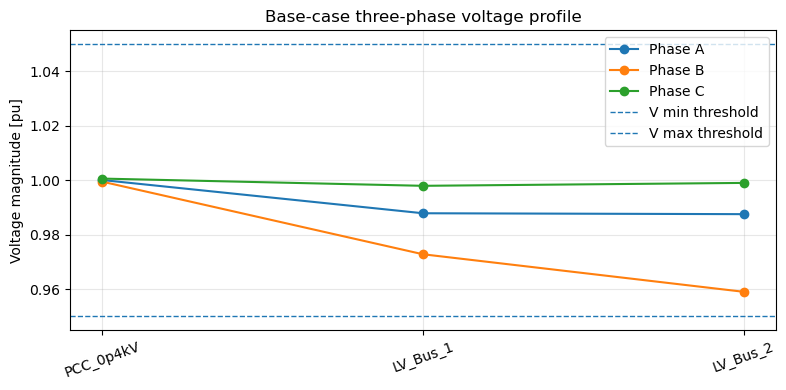

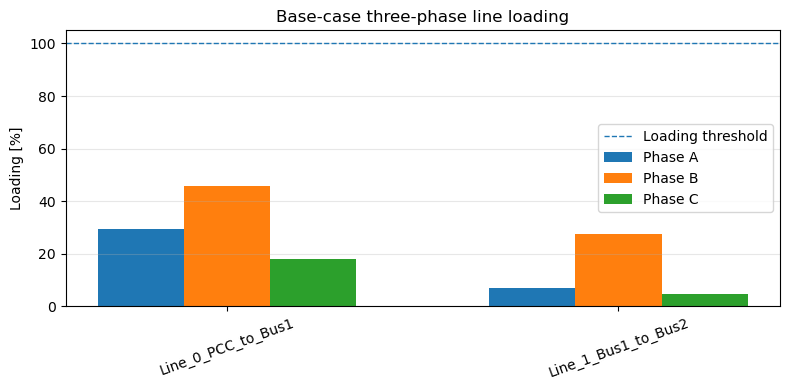

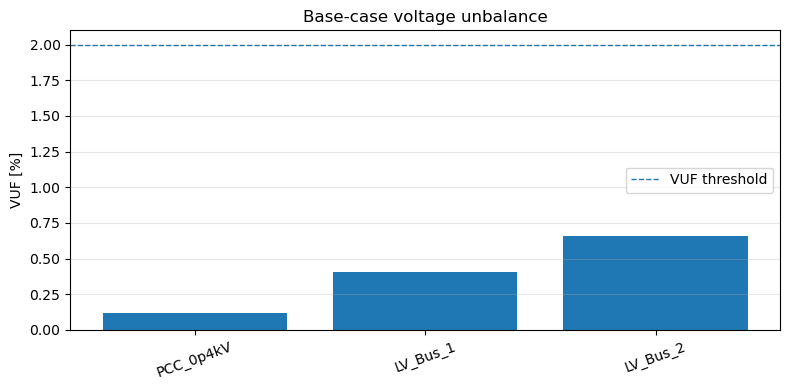

In [12]:
def plot_three_phase_voltage_profile(net: pp.pandapowerNet, title: str = "Three-phase voltage profile") -> None:
    rb = net.res_bus_3ph
    x = np.arange(len(rb))
    plt.figure(figsize=(8, 4))
    for ph in PHASES:
        plt.plot(x, rb[f"vm_{ph}_pu"].to_numpy(), marker="o", label=f"Phase {ph.upper()}")
    plt.axhline(V_MIN_PU, linestyle="--", linewidth=1, label="V min threshold")
    plt.axhline(V_MAX_PU, linestyle="--", linewidth=1, label="V max threshold")
    plt.xticks(x, net.bus["name"].astype(str).to_list(), rotation=20)
    plt.ylabel("Voltage magnitude [pu]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_three_phase_line_loading(net: pp.pandapowerNet, title: str = "Three-phase line loading") -> None:
    rl = net.res_line_3ph
    x = np.arange(len(rl))
    width = 0.22
    plt.figure(figsize=(8, 4))
    for offset, ph in zip([-width, 0.0, width], PHASES):
        plt.bar(x + offset, rl[f"loading_{ph}_percent"].to_numpy(), width=width, label=f"Phase {ph.upper()}")
    plt.axhline(LOADING_MAX_PERCENT, linestyle="--", linewidth=1, label="Loading threshold")
    plt.xticks(x, net.line["name"].astype(str).to_list(), rotation=20)
    plt.ylabel("Loading [%]")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_bus_unbalance(net: pp.pandapowerNet, title: str = "Voltage unbalance factor") -> None:
    rb = net.res_bus_3ph
    x = np.arange(len(rb))
    plt.figure(figsize=(8, 4))
    plt.bar(x, rb["unbalance_percent"].to_numpy())
    plt.axhline(VUF_MAX_PERCENT, linestyle="--", linewidth=1, label="VUF threshold")
    plt.xticks(x, net.bus["name"].astype(str).to_list(), rotation=20)
    plt.ylabel("VUF [%]")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_three_phase_voltage_profile(net, "Base-case three-phase voltage profile")
plot_three_phase_line_loading(net, "Base-case three-phase line loading")
plot_bus_unbalance(net, "Base-case voltage unbalance")

## 12. Cross-validation — balanced case with `runpp()` vs `runpp_3ph()`

当三相完全对称时，三相潮流结果应该与等效 balanced power flow 结果接近。这个测试可以帮助我们确认：

- bus nominal voltage 的理解正确；
- 每相功率与三相总功率的换算正确；
- line current / loading 的换算正确；
- `runpp_3ph` 的基础设置没有明显错误。

In [13]:
def create_equivalent_balanced_power_flow_net() -> pp.pandapowerNet:
    """Create a balanced runpp() network equivalent to create_three_phase_teaching_feeder(False)."""
    net = pp.create_empty_network(name="week2_equivalent_balanced_feeder", sn_mva=1.0)

    b_pcc = pp.create_bus(net, vn_kv=0.4, name="PCC_0p4kV")
    b_1 = pp.create_bus(net, vn_kv=0.4, name="LV_Bus_1")
    b_2 = pp.create_bus(net, vn_kv=0.4, name="LV_Bus_2")

    pp.create_ext_grid(net, bus=b_pcc, vm_pu=1.0, va_degree=0.0, name="PCC_slack")

    for from_bus, to_bus, length_km, name in [
        (b_pcc, b_1, 0.08, "Line_0_PCC_to_Bus1"),
        (b_1, b_2, 0.06, "Line_1_Bus1_to_Bus2"),
    ]:
        pp.create_line_from_parameters(
            net,
            from_bus=from_bus,
            to_bus=to_bus,
            length_km=length_km,
            r_ohm_per_km=0.642,
            x_ohm_per_km=0.083,
            c_nf_per_km=210.0,
            max_i_ka=0.20,
            name=name,
        )

    # Equivalent total three-phase powers.
    pp.create_load(net, bus=b_1, p_mw=3 * 0.008, q_mvar=3 * 0.0016, name="Bus1_balanced_total_load")
    pp.create_load(net, bus=b_2, p_mw=3 * 0.006, q_mvar=3 * 0.0012, name="Bus2_balanced_total_load")
    pp.create_sgen(net, bus=b_2, p_mw=3 * 0.002, q_mvar=0.0, name="Bus2_balanced_total_PV")
    return net


def compare_balanced_runpp_and_runpp3ph() -> pd.DataFrame:
    net3 = create_three_phase_teaching_feeder(unbalanced=False)
    net1 = create_equivalent_balanced_power_flow_net()

    run_three_phase_power_flow(net3)
    pp.runpp(net1, calculate_voltage_angles=True, algorithm="nr", tolerance_mva=1e-8)
    if not net1.converged:
        raise AssertionError("Balanced runpp() did not converge.")

    rows = []
    for bus_idx in net1.bus.index:
        vm_1ph = float(net1.res_bus.loc[bus_idx, "vm_pu"])
        vm_3ph_mean = float(net3.res_bus_3ph.loc[bus_idx, ["vm_a_pu", "vm_b_pu", "vm_c_pu"]].mean())
        max_phase_spread = float(
            net3.res_bus_3ph.loc[bus_idx, ["vm_a_pu", "vm_b_pu", "vm_c_pu"]].max()
            - net3.res_bus_3ph.loc[bus_idx, ["vm_a_pu", "vm_b_pu", "vm_c_pu"]].min()
        )
        rows.append(
            {
                "type": "bus_voltage",
                "index": bus_idx,
                "balanced_runpp": vm_1ph,
                "three_phase_mean_or_value": vm_3ph_mean,
                "abs_error": abs(vm_1ph - vm_3ph_mean),
                "three_phase_spread": max_phase_spread,
            }
        )

    for line_idx in net1.line.index:
        loading_1ph = float(net1.res_line.loc[line_idx, "loading_percent"])
        loading_3ph = float(net3.res_line_3ph.loc[line_idx, "loading_percent"])
        rows.append(
            {
                "type": "line_loading",
                "index": line_idx,
                "balanced_runpp": loading_1ph,
                "three_phase_mean_or_value": loading_3ph,
                "abs_error": abs(loading_1ph - loading_3ph),
                "three_phase_spread": np.nan,
            }
        )

    comparison = pd.DataFrame(rows)
    max_vm_error = comparison.loc[comparison["type"] == "bus_voltage", "abs_error"].max()
    max_loading_error = comparison.loc[comparison["type"] == "line_loading", "abs_error"].max()
    max_phase_spread = comparison.loc[comparison["type"] == "bus_voltage", "three_phase_spread"].max()

    print(f"Max bus voltage error between runpp and runpp_3ph = {max_vm_error:.3e} pu")
    print(f"Max line loading error between runpp and runpp_3ph = {max_loading_error:.3e} percent")
    print(f"Max A/B/C voltage spread in balanced three-phase case = {max_phase_spread:.3e} pu")

    if max_vm_error > TOL_BALANCED_VM_PU:
        raise AssertionError("Balanced runpp vs runpp_3ph voltage cross-check failed.")
    if max_loading_error > TOL_BALANCED_LOADING_PERCENT:
        raise AssertionError("Balanced runpp vs runpp_3ph loading cross-check failed.")
    if max_phase_spread > TOL_BALANCED_VM_PU:
        raise AssertionError("Balanced runpp_3ph case is not sufficiently phase-balanced.")
    return comparison


balanced_cross_check = compare_balanced_runpp_and_runpp3ph()
display(balanced_cross_check)

Input network validation passed.


Result table validation passed.
Max bus voltage error between runpp and runpp_3ph = 2.555e-11 pu
Max line loading error between runpp and runpp_3ph = 5.187e-08 percent
Max A/B/C voltage spread in balanced three-phase case = 1.110e-16 pu


,type,index,balanced_runpp,three_phase_mean_or_value,abs_error,three_phase_spread
0,bus_voltage,0,1.000000,1.000000,0.000000e+00,0.000000e+00
1,bus_voltage,1,0.987936,0.987936,2.338485e-11,1.110223e-16
2,bus_voltage,2,0.984889,0.984889,2.554856e-11,1.110223e-16
3,line_loading,0,27.032859,27.032859,5.187357e-08,NaN
4,line_loading,1,9.180292,9.180292,6.330025e-09,NaN


## 13. Scenario experiments for engineering intuition

本周不做大规模数据集，只做几个小场景来建立工程直觉。

- `base`: 基准不平衡场景；
- `high_load`: 三相负荷整体升高；
- `phase_b_heavy_load`: B 相负荷显著升高；
- `single_phase_pv_a`: A 相 PV 增大；
- `stress_unbalance`: 强相间不平衡，用于观察 voltage/loading/VUF 越限。

In [14]:
# Scenario dictionary: each case changes only per-phase P/Q scaling, not topology.
# This keeps comparisons focused on operating point and imbalance effects.
SCENARIOS = {
    "base": {
        "load_scale": {"a": 1.0, "b": 1.0, "c": 1.0},
        "sgen_scale": {"a": 1.0, "b": 1.0, "c": 1.0},
    },
    "high_load": {
        "load_scale": {"a": 1.6, "b": 1.6, "c": 1.6},
        "sgen_scale": {"a": 1.0, "b": 1.0, "c": 1.0},
    },
    "phase_b_heavy_load": {
        "load_scale": {"a": 0.9, "b": 2.5, "c": 0.9},
        "sgen_scale": {"a": 1.0, "b": 1.0, "c": 1.0},
    },
    "single_phase_pv_a": {
        "load_scale": {"a": 1.0, "b": 1.0, "c": 1.0},
        "sgen_scale": {"a": 4.0, "b": 1.0, "c": 1.0},
    },
    "stress_unbalance": {
        "load_scale": {"a": 0.8, "b": 3.0, "c": 0.8},
        "sgen_scale": {"a": 4.5, "b": 1.0, "c": 0.5},
    },
}


def apply_scenario(net: pp.pandapowerNet, scenario_spec: Dict[str, Dict[str, float]]) -> pp.pandapowerNet:
    """Apply per-phase scaling to asymmetric load and sgen tables."""
    load_scale = scenario_spec["load_scale"]
    sgen_scale = scenario_spec["sgen_scale"]

    for ph in PHASES:
        # Scaling both P and Q preserves the original power factor of each phase.
        net.asymmetric_load[f"p_{ph}_mw"] *= load_scale[ph]
        net.asymmetric_load[f"q_{ph}_mvar"] *= load_scale[ph]
        net.asymmetric_sgen[f"p_{ph}_mw"] *= sgen_scale[ph]
        net.asymmetric_sgen[f"q_{ph}_mvar"] *= sgen_scale[ph]
    return net


def run_scenario(scenario_name: str, scenario_spec: Dict[str, Dict[str, float]]) -> Tuple[pp.pandapowerNet, pd.Series]:
    scenario_net = create_three_phase_teaching_feeder(unbalanced=True)
    apply_scenario(scenario_net, scenario_spec)
    run_three_phase_power_flow(scenario_net)
    summary = summarize_three_phase_security(scenario_net, scenario_name=scenario_name)
    return scenario_net, summary


def run_all_scenarios() -> Tuple[Dict[str, pp.pandapowerNet], pd.DataFrame]:
    nets = {}
    summaries = []
    for scenario_name, scenario_spec in SCENARIOS.items():
        scenario_net, summary = run_scenario(scenario_name, scenario_spec)
        nets[scenario_name] = scenario_net
        summaries.append(summary)
    summary_df = pd.DataFrame(summaries).set_index("scenario")
    return nets, summary_df


scenario_nets, scenario_summary = run_all_scenarios()
display(scenario_summary)

Input network validation passed.
Result table validation passed.
Input network validation passed.
Result table validation passed.
Input network validation passed.
Result table validation passed.


Input network validation passed.


Result table validation passed.


Input network validation passed.
Result table validation passed.


,converged,min_vm_a_pu,min_vm_b_pu,min_vm_c_pu,min_vm_all_pu,max_vm_all_pu,max_unbalance_percent,max_loading_a_percent,max_loading_b_percent,max_loading_c_percent,max_loading_percent,p_grid_total_mw,q_grid_total_mvar,voltage_violation,loading_violation,unbalance_violation,any_static_violation
scenario,,,,,,,,,,,,,,,,,
base,True,0.987498,0.958988,0.997905,0.958988,1.000558,0.656323,29.349975,45.786262,17.883890,45.786262,0.041924,0.009320,False,False,False,False
high_load,True,0.975840,0.934354,0.995326,0.934354,1.000908,1.042200,51.335862,74.924227,31.228683,74.924227,0.071142,0.015051,True,False,False,True
phase_b_heavy_load,True,1.001381,0.873539,1.001728,0.873539,1.015710,2.637329,25.339557,124.170381,15.468502,124.170381,0.074437,0.015486,True,True,True,True
single_phase_pv_a,True,1.000215,0.952885,0.995699,0.952885,1.012069,0.889214,13.089668,46.029570,17.922913,46.029570,0.032960,0.009327,False,False,False,False
stress_unbalance,True,1.002060,0.832191,1.002068,0.832191,1.048655,3.656452,18.071128,155.344738,15.327069,155.344738,0.076699,0.017562,True,True,True,True


## 14. Scenario sanity checks

这些不是数学定理，而是工程直觉检查：

1. `high_load` 的最小电压应低于 `base`；
2. `single_phase_pv_a` 的外部电网总有功进口应低于 `base`；
3. `stress_unbalance` 的最大 VUF 应高于 `base`；
4. `phase_b_heavy_load` 中 B 相最低电压应明显低于 base 的 B 相最低电压。

In [15]:
def run_scenario_sanity_checks(summary_df: pd.DataFrame) -> None:
    base = summary_df.loc["base"]

    if not (summary_df.loc["high_load", "min_vm_all_pu"] < base["min_vm_all_pu"]):
        raise AssertionError("Expected high_load to reduce the minimum voltage.")

    if not (summary_df.loc["single_phase_pv_a", "p_grid_total_mw"] < base["p_grid_total_mw"]):
        raise AssertionError("Expected single_phase_pv_a to reduce grid active power import.")

    if not (summary_df.loc["stress_unbalance", "max_unbalance_percent"] > base["max_unbalance_percent"]):
        raise AssertionError("Expected stress_unbalance to increase voltage unbalance.")

    if not (summary_df.loc["phase_b_heavy_load", "min_vm_b_pu"] < base["min_vm_b_pu"]):
        raise AssertionError("Expected phase_b_heavy_load to reduce phase-B voltage.")

    print("Scenario sanity checks passed.")


run_scenario_sanity_checks(scenario_summary)

Scenario sanity checks passed.


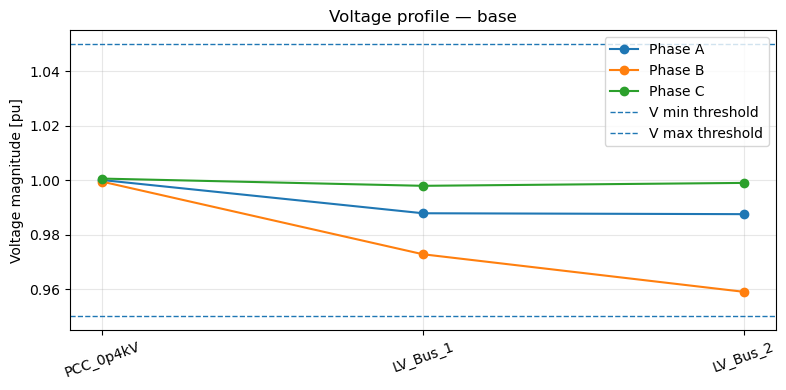

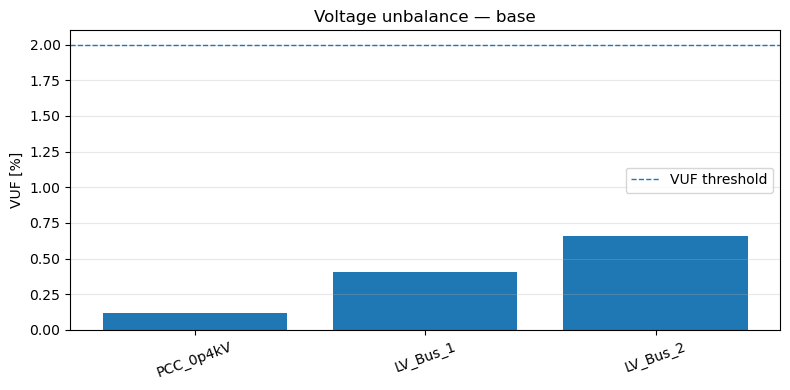

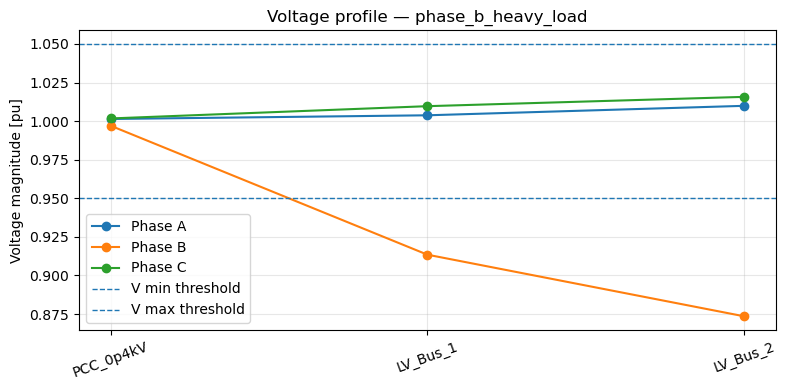

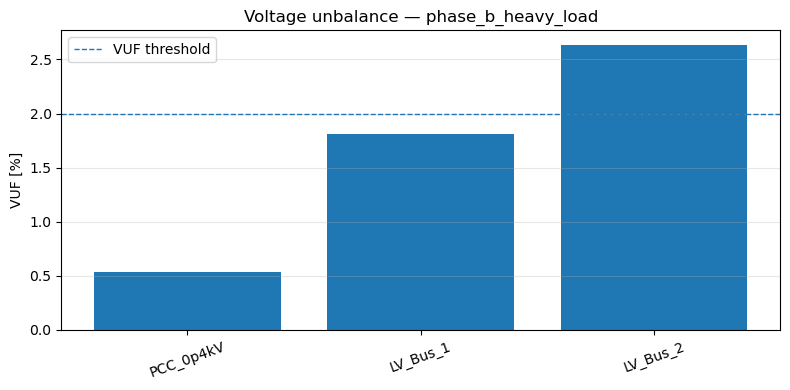

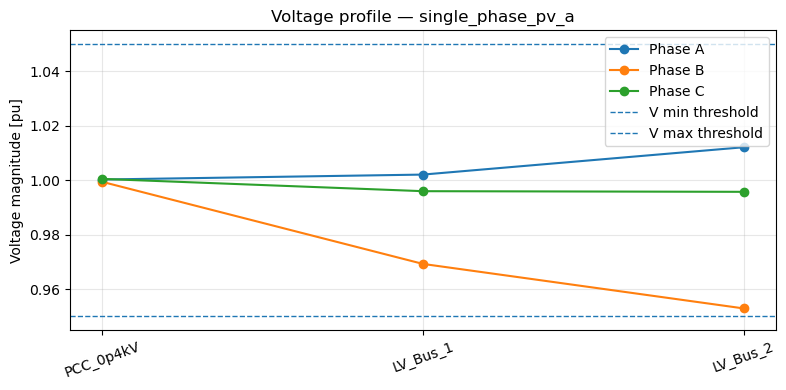

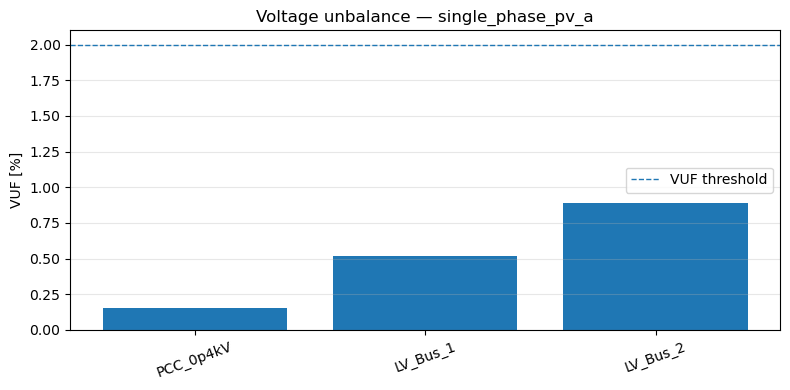

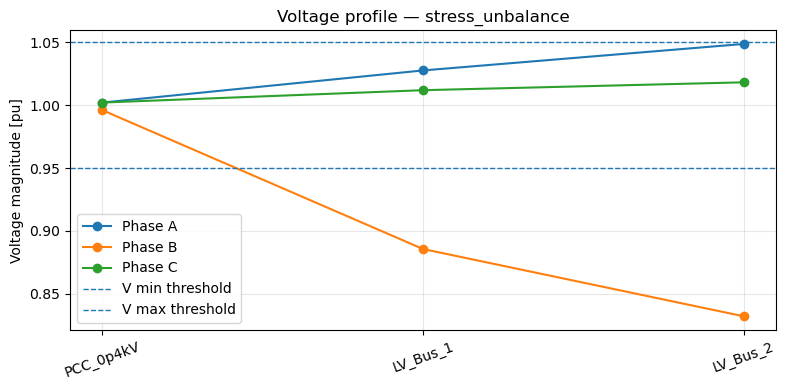

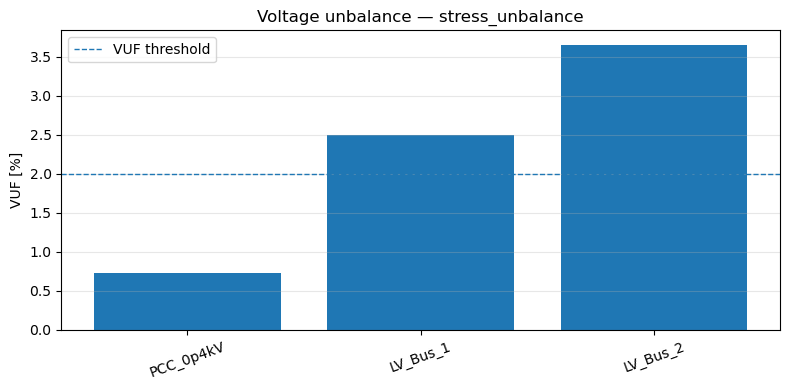

In [16]:
# Visualize selected scenarios.
for name in ["base", "phase_b_heavy_load", "single_phase_pv_a", "stress_unbalance"]:
    plot_three_phase_voltage_profile(scenario_nets[name], title=f"Voltage profile — {name}")
    plot_bus_unbalance(scenario_nets[name], title=f"Voltage unbalance — {name}")

## 15. Regression-test bundle — 一键复核所有 proof

科研代码中建议保留这样的 regression-test bundle：当你改动网络、参数、场景或特征提取代码后，重新运行所有 proof。只要其中一个断言失败，就先修正数据生成逻辑，再训练 AI。

In [17]:
def run_all_week2_validation_tests() -> pd.DataFrame:
    """Run proof and cross-validation tests for base and all scenario networks."""
    rows = []

    all_nets = {"base_initial": net, **scenario_nets}
    for name, n in all_nets.items():
        validate_input_network(n)
        validate_result_tables(n)
        seq = validate_vuf_against_pandapower(n)
        bal = validate_per_phase_power_balance(n)
        cur = validate_phase_currents_from_s_equals_vi(n)
        load = validate_line_loading_formula(n)
        rows.append(
            {
                "case": name,
                "max_vuf_error_percent": float(seq["VUF_error_percent"].abs().max()),
                "max_p_balance_residual_mw": float(bal["p_residual_mw"].abs().max()),
                "max_q_balance_residual_mvar": float(bal["q_residual_mvar"].abs().max()),
                "max_current_error_ka": float(cur["error_ka"].abs().max()),
                "max_loading_error_percent": float(load["error_percent"].abs().max()),
            }
        )

    # Also rerun the balanced runpp vs runpp_3ph cross-check.
    comparison = compare_balanced_runpp_and_runpp3ph()
    rows.append(
        {
            "case": "balanced_runpp_vs_runpp3ph",
            "max_vuf_error_percent": np.nan,
            "max_p_balance_residual_mw": np.nan,
            "max_q_balance_residual_mvar": np.nan,
            "max_current_error_ka": np.nan,
            "max_loading_error_percent": float(comparison["abs_error"].max()),
        }
    )

    run_scenario_sanity_checks(scenario_summary)
    test_summary = pd.DataFrame(rows).set_index("case")
    print("All Week 2 validation tests passed.")
    return test_summary


validation_test_summary = run_all_week2_validation_tests()
display(validation_test_summary)

Input network validation passed.
Result table validation passed.
Max VUF error = 9.437e-15 percent
Max P residual = 1.936e-09 MW
Max Q residual = 4.951e-10 Mvar
Max current error = 2.776e-17 kA
Max loading error = 7.105e-15 percent
Input network validation passed.
Result table validation passed.
Max VUF error = 9.437e-15 percent
Max P residual = 1.936e-09 MW
Max Q residual = 4.951e-10 Mvar
Max current error = 2.776e-17 kA
Max loading error = 7.105e-15 percent
Input network validation passed.
Result table validation passed.
Max VUF error = 7.327e-15 percent
Max P residual = 3.032e-09 MW
Max Q residual = 5.894e-10 Mvar
Max current error = 2.776e-17 kA
Max loading error = 3.553e-15 percent
Input network validation passed.
Result table validation passed.
Max VUF error = 1.033e-14 percent
Max P residual = 3.378e-09 MW
Max Q residual = 6.111e-10 Mvar
Max current error = 8.327e-17 kA
Max loading error = 1.421e-14 percent
Input network validation passed.
Result table validation passed.
Max VUF

,max_vuf_error_percent,max_p_balance_residual_mw,max_q_balance_residual_mvar,max_current_error_ka,max_loading_error_percent
case,,,,,
base_initial,9.436896e-15,1.935803e-09,4.951406e-10,2.775558e-17,7.105427e-15
base,9.436896e-15,1.935803e-09,4.951406e-10,2.775558e-17,7.105427e-15
high_load,7.327472e-15,3.031897e-09,5.894273e-10,2.775558e-17,3.552714e-15
phase_b_heavy_load,1.032507e-14,3.378137e-09,6.110996e-10,8.326673e-17,1.421085e-14
single_phase_pv_a,1.243450e-14,2.756187e-09,4.215860e-10,2.775558e-17,3.552714e-15
stress_unbalance,1.243450e-14,6.563188e-09,1.250743e-09,5.551115e-17,0.000000e+00
balanced_runpp_vs_runpp3ph,NaN,NaN,NaN,NaN,5.187357e-08


## 16. Export Week 2 summary and figures

Week 5 的 ML baseline 和 Week 7 的 GNN 会用到类似的 features。这里先导出一个很小的 scenario-level summary。

In [18]:
output_dir = OUTPUT_DIR
output_dir.mkdir(parents=True, exist_ok=True)

scenario_summary_path = output_dir / "week2_scenario_security_summary.csv"
scenario_summary.to_csv(scenario_summary_path)

validation_summary_path = output_dir / "week2_validation_test_summary.csv"
validation_test_summary.to_csv(validation_summary_path)

print(f"Saved: {scenario_summary_path}")
print(f"Saved: {validation_summary_path}")

Saved: /Users/buxinshe/Git-repo/PINN-Microgrid-Prediction/02_week02_three_phase_power_flow/outputs/week2_scenario_security_summary.csv
Saved: /Users/buxinshe/Git-repo/PINN-Microgrid-Prediction/02_week02_three_phase_power_flow/outputs/week2_validation_test_summary.csv


## 17. Student exercises

### Exercise 1 — Create a healthier base case

修改 `create_three_phase_teaching_feeder()` 中的负荷或线路长度，使 base-case 的：

```text
min_vm_all_pu > 0.97
max_unbalance_percent < 1.0
```

然后重新运行所有 proof。

---

### Exercise 2 — Create a voltage violation

修改 `SCENARIOS["stress_unbalance"]`，使某一相电压低于 0.90 pu，同时潮流仍然收敛。

---

### Exercise 3 — Create a high PV case

修改 `single_phase_pv_a`，观察 A 相电压变化。回答：

> 单相 PV 增大时，为什么并不一定只影响 A 相？

---

### Exercise 4 — Prepare for Week 3

如果 feeder 从 3 个 bus 扩展到几百个 bus，你会如何组织：

```text
bus-level features
line-level features
scenario-level features
```

这些会变成 Week 5 和 Week 7 的 AI input。

## 18. 本周小结

本周你已经完成了三相安全预测最关键的一步：**可信的三相潮流计算**。

后续课程中，这些内容会这样被复用：

- Week 3：把运行点扩展为大量 microgrid scenarios；
- Week 4：对每个 scenario 执行 N-1 contingency，生成 phase-aware violation labels；
- Week 5：把 base-case features 输入传统 ML；
- Week 6：把 voltage/current/VUF penalty 加入 physics-informed loss；
- Week 7：把 bus/line/phase/channel 信息放入 GNN。

如果本周 proof 没有通过，不要进入 AI 训练。先修复物理建模和数据生成。

## 19. Case Study for Paper

The final cells introduce three pandapower built-in cases that can later become the paper's benchmark systems. The goal here is not to tune an AI model yet; it is to make sure each case can be loaded, solved, printed, and visualized in a repeatable way.

| Paper case | Source network | Solver | Role |
| --- | --- | --- | --- |
| **P-ELV-R50-MG** | `pn.ieee_european_lv_asymmetric("on_peak_566")`, automatically reduced to a connected 50-100 bus LV subnet | `pp.runpp_3ph()` | small debugging / ablation case |
| **P-ELV906-MG** | full `pn.ieee_european_lv_asymmetric("on_peak_566")` with `off_peak_1` and `off_peak_1440` as OOD operating scenarios | `pp.runpp_3ph()` | large paper-scale unbalanced LV case |
| **CIGRE-MV-DER-MG** | `pn.create_cigre_network_mv(with_der="all")` | `pp.runpp()` | supplementary DER-rich MV validation case |

Benchmark check: pandapower documents the European LV feeder as a generic 0.416 kV network supplied by one 0.8 MVA MV/LV transformer, with 906 LV buses and 55 single-phase loads. The pandapower object reports 907 buses because it also includes the source-side bus. The CIGRE-MV-DER case is DER-rich but is not shipped as an asymmetric three-phase network with the zero-sequence data required by `runpp_3ph()`, so we use it as a balanced DER-rich supplementary case. With the validated pandapower 3.2.1 environment, the 15 all-DER elements are represented as 13 `sgen` elements plus 2 `storage` elements; table placement can differ by pandapower release.


In [19]:
import copy
from typing import Dict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.networks as pn
import pandapower.topology as top

# Fallbacks make this paper-case module runnable even if copied out of the notebook.
PAPER_V_MIN_PU = globals().get("V_MIN_PU", 0.95)
PAPER_V_MAX_PU = globals().get("V_MAX_PU", 1.05)
PAPER_LOADING_MAX_PERCENT = globals().get("LOADING_MAX_PERCENT", 100.0)
PAPER_VUF_MAX_PERCENT = globals().get("VUF_MAX_PERCENT", 2.0)

# Paper-case constants keep the case definitions visible and easy to cite later.
PAPER_SMALL_TARGET_RANGE = (50, 100)
PAPER_SMALL_MIN_ASYMMETRIC_LOADS = 5
ELV_BASE_SCENARIO = "on_peak_566"
ELV_OOD_SCENARIOS = ["off_peak_1", "off_peak_1440"]


def _display_or_print(obj) -> None:
    """Use rich notebook display when available; fall back to plain text otherwise."""
    try:
        display(obj)  # noqa: F821
    except NameError:
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)


def _table_len(net: pp.pandapowerNet, table: str) -> int:
    return int(len(net[table])) if table in net else 0


def _source_bus(net: pp.pandapowerNet) -> int:
    if len(net.ext_grid) == 0:
        raise ValueError("The network has no ext_grid/source bus.")
    return int(net.ext_grid.bus.iloc[0])


def _nearest_connected_buses(net: pp.pandapowerNet, root_bus: int) -> list[int]:
    graph = top.create_nxgraph(
        net,
        include_switches=True,
        include_out_of_service=False,
        multi=False,
    )
    lengths = nx.single_source_shortest_path_length(graph, root_bus)
    return [bus for bus, _ in sorted(lengths.items(), key=lambda item: (item[1], item[0]))]


def _active_power_in_asymmetric_loads(net: pp.pandapowerNet, buses: set[int]) -> float:
    if _table_len(net, "asymmetric_load") == 0:
        return 0.0
    mask = net.asymmetric_load.bus.astype(int).isin(buses)
    p_cols = [col for col in ["p_a_mw", "p_b_mw", "p_c_mw"] if col in net.asymmetric_load]
    return float(net.asymmetric_load.loc[mask, p_cols].sum().sum()) if p_cols else 0.0


def _source_connected_load_rich_buses(
    net: pp.pandapowerNet,
    min_buses: int,
    max_buses: int,
    min_asymmetric_loads: int,
) -> list[int]:
    """Pick a compact source-connected subnet that contains enough actual load to be visible."""
    source = _source_bus(net)
    graph = top.create_nxgraph(
        net,
        include_switches=True,
        include_out_of_service=False,
        multi=False,
    )
    source_distances = nx.single_source_shortest_path_length(graph, source)
    load_buses = set(net.asymmetric_load.bus.astype(int)) if _table_len(net, "asymmetric_load") else set()
    best_score = None
    best_buses = None

    # Search around actual load buses, not merely the nearest source buses; otherwise the reduced case
    # can look artificially flat because it contains too little downstream loading.
    for center in sorted(load_buses):
        if center not in source_distances:
            continue
        path_to_source = set(nx.shortest_path(graph, source, center))
        neighborhood = nx.single_source_shortest_path_length(graph, center, cutoff=max_buses)
        for radius in range(max_buses + 1):
            candidate_buses = {bus for bus, distance in neighborhood.items() if distance <= radius} | path_to_source
            if len(candidate_buses) > max_buses:
                break
            load_count = len(candidate_buses & load_buses)
            if len(candidate_buses) < min_buses or load_count < min_asymmetric_loads:
                continue
            total_p = _active_power_in_asymmetric_loads(net, candidate_buses)
            depth = max(source_distances.get(bus, 0) for bus in candidate_buses)
            # Prefer more loads, more active power, deeper feeder reach, then the smaller subnet.
            score = (load_count, total_p, depth, -len(candidate_buses))
            if best_score is None or score > best_score:
                best_score = score
                best_buses = candidate_buses
            break

    if best_buses is None:
        ordered_buses = _nearest_connected_buses(net, source)
        best_buses = set(ordered_buses[:min(max_buses, len(ordered_buses))])

    ordered = sorted(best_buses, key=lambda bus: (source_distances.get(bus, 10**9), bus))
    return ordered


def create_p_elv_r50_mg(
    scenario: str = ELV_BASE_SCENARIO,
    min_buses: int = PAPER_SMALL_TARGET_RANGE[0],
    max_buses: int = PAPER_SMALL_TARGET_RANGE[1],
    min_asymmetric_loads: int = PAPER_SMALL_MIN_ASYMMETRIC_LOADS,
) -> pp.pandapowerNet:
    """Create a connected 50-100 bus reduced LV case from pandapower's asymmetric ELV feeder."""
    base = pn.ieee_european_lv_asymmetric(scenario)
    selected_buses = _source_connected_load_rich_buses(
        base,
        min_buses=min_buses,
        max_buses=max_buses,
        min_asymmetric_loads=min_asymmetric_loads,
    )
    selected_net = pp.select_subnet(
        base,
        buses=selected_buses,
        include_switch_buses=True,
        include_results=False,
        keep_everything_else=False,
    )
    selected_net.name = (
        f"P-ELV-R50-MG ({scenario}, {len(selected_net.bus)} buses, "
        f"{_table_len(selected_net, 'asymmetric_load')} 1-phase loads)"
    )
    return selected_net


def create_p_elv906_mg(scenario: str = ELV_BASE_SCENARIO) -> pp.pandapowerNet:
    """Load the full pandapower European LV asymmetric network for one operating scenario."""
    net = pn.ieee_european_lv_asymmetric(scenario)
    net.name = f"P-ELV906-MG ({scenario})"
    return net


def create_cigre_mv_der_mg() -> pp.pandapowerNet:
    """Load pandapower's DER-rich CIGRE MV benchmark as a balanced supplementary case."""
    net = pn.create_cigre_network_mv(with_der="all")
    net.name = "CIGRE-MV-DER-MG"
    return net


def run_paper_case_power_flow(
    net: pp.pandapowerNet,
    solver: str,
) -> pp.pandapowerNet:
    """Run the appropriate pandapower solver and return a solved copy."""
    net = copy.deepcopy(net)
    # Solver choice is part of the case definition: ELV is asymmetric 3-phase, CIGRE-MV-DER is balanced.
    if solver == "runpp_3ph":
        pp.runpp_3ph(
            net,
            calculate_voltage_angles=True,
            init="auto",
            max_iteration=50,
            tolerance_mva=1e-8,
        )
    elif solver == "runpp":
        pp.runpp(
            net,
            calculate_voltage_angles=True,
            algorithm="nr",
            max_iteration=50,
            tolerance_mva=1e-8,
        )
    else:
        raise ValueError(f"Unknown solver: {solver}")
    if not bool(net.converged):
        raise RuntimeError(f"{getattr(net, 'name', 'case')} did not converge with {solver}.")
    return net


def summarize_paper_case(
    case_key: str,
    net: pp.pandapowerNet,
    solver: str,
    scenario: str,
    role: str,
) -> pd.Series:
    """Create a compact case-level result row for paper tables."""
    if solver == "runpp_3ph":
        vm_cols = ["vm_a_pu", "vm_b_pu", "vm_c_pu"]
        loading = float(net.res_line_3ph["loading_percent"].max()) if _table_len(net, "line") else np.nan
        p_grid = float(net.res_ext_grid_3ph[["p_a_mw", "p_b_mw", "p_c_mw"]].sum().sum())
        max_vuf = float(net.res_bus_3ph["unbalance_percent"].max())
        min_vm = float(net.res_bus_3ph[vm_cols].min().min())
        max_vm = float(net.res_bus_3ph[vm_cols].max().max())
    else:
        loading = float(net.res_line["loading_percent"].max()) if _table_len(net, "line") else np.nan
        p_grid = float(net.res_ext_grid["p_mw"].sum()) if _table_len(net, "ext_grid") else np.nan
        max_vuf = np.nan
        min_vm = float(net.res_bus["vm_pu"].min())
        max_vm = float(net.res_bus["vm_pu"].max())

    return pd.Series(
        {
            "role": role,
            "scenario": scenario,
            "solver": solver,
            "n_bus": _table_len(net, "bus"),
            "n_line": _table_len(net, "line"),
            "n_trafo": _table_len(net, "trafo"),
            "n_asymmetric_load": _table_len(net, "asymmetric_load"),
            "n_load": _table_len(net, "load"),
            "n_sgen": _table_len(net, "sgen"),
            "n_storage": _table_len(net, "storage"),
            "n_der_elements": _table_len(net, "sgen") + _table_len(net, "storage"),
            "converged": bool(net.converged),
            "min_vm_pu": min_vm,
            "max_vm_pu": max_vm,
            "max_loading_percent": loading,
            "max_vuf_percent": max_vuf,
            "p_grid_total_mw": p_grid,
        },
        name=case_key,
    )


def build_paper_case_specs() -> list[dict]:
    specs = [
        {
            "case_key": "P-ELV-R50-MG",
            "role": "small reduced LV microgrid case",
            "scenario": ELV_BASE_SCENARIO,
            "solver": "runpp_3ph",
            "builder": lambda: create_p_elv_r50_mg(ELV_BASE_SCENARIO),
        },
        {
            "case_key": f"P-ELV906-MG_{ELV_BASE_SCENARIO}",
            "role": "large in-domain LV case",
            "scenario": ELV_BASE_SCENARIO,
            "solver": "runpp_3ph",
            "builder": lambda: create_p_elv906_mg(ELV_BASE_SCENARIO),
        },
    ]
    for scenario in ELV_OOD_SCENARIOS:
        specs.append(
            {
                "case_key": f"P-ELV906-MG_{scenario}",
                "role": "large OOD LV operating scenario",
                "scenario": scenario,
                "solver": "runpp_3ph",
                "builder": lambda scenario=scenario: create_p_elv906_mg(scenario),
            }
        )
    specs.append(
        {
            "case_key": "CIGRE-MV-DER-MG",
            "role": "supplementary DER-rich MV case",
            "scenario": "with_der=all",
            "solver": "runpp",
            "builder": create_cigre_mv_der_mg,
        }
    )
    return specs


def run_paper_case_study() -> tuple[Dict[str, pp.pandapowerNet], pd.DataFrame, Dict[str, str]]:
    """Build, solve, and summarize all paper case-study networks."""
    nets: Dict[str, pp.pandapowerNet] = {}
    solver_by_case: Dict[str, str] = {}
    summary_rows = []
    for spec in build_paper_case_specs():
        print(f"Running {spec['case_key']} with {spec['solver']} ...")
        solved_net = run_paper_case_power_flow(spec["builder"](), solver=spec["solver"])
        nets[spec["case_key"]] = solved_net
        solver_by_case[spec["case_key"]] = spec["solver"]
        summary_rows.append(
            summarize_paper_case(
                case_key=spec["case_key"],
                net=solved_net,
                solver=spec["solver"],
                scenario=spec["scenario"],
                role=spec["role"],
            )
        )
    summary = pd.DataFrame(summary_rows)
    summary.index.name = "paper_case"
    return nets, summary, solver_by_case


### 19.1 Run the paper cases

This cell runs the power flow for each case and creates a compact summary table. The full ELV case is solved three times: one in-domain operating point and two OOD operating points.


In [20]:
paper_case_nets, paper_case_summary, paper_case_solvers = run_paper_case_study()
_display_or_print(paper_case_summary.round(6))


Running P-ELV-R50-MG with runpp_3ph ...


Running P-ELV906-MG_on_peak_566 with runpp_3ph ...


Running P-ELV906-MG_off_peak_1 with runpp_3ph ...


Running P-ELV906-MG_off_peak_1440 with runpp_3ph ...


Running CIGRE-MV-DER-MG with runpp ...


,role,scenario,solver,n_bus,n_line,n_trafo,n_asymmetric_load,n_load,n_sgen,n_storage,n_der_elements,converged,min_vm_pu,max_vm_pu,max_loading_percent,max_vuf_percent,p_grid_total_mw
paper_case,,,,,,,,,,,,,,,,,
P-ELV-R50-MG,small reduced LV microgrid case,on_peak_566,runpp_3ph,81,79,1,6,0,0,0,0,True,1.046391,1.051201,2.950607,0.088369,0.006175
P-ELV906-MG_on_peak_566,large in-domain LV case,on_peak_566,runpp_3ph,907,905,1,55,0,0,0,0,True,0.996239,1.067973,33.201211,0.731202,0.059426
P-ELV906-MG_off_peak_1,large OOD LV operating scenario,off_peak_1,runpp_3ph,907,905,1,55,0,0,0,0,True,1.048856,1.050000,1.048037,0.010568,0.002799
P-ELV906-MG_off_peak_1440,large OOD LV operating scenario,off_peak_1440,runpp_3ph,907,905,1,55,0,0,0,0,True,1.045357,1.050000,3.690535,0.047966,0.009721
CIGRE-MV-DER-MG,supplementary DER-rich MV case,with_der=all,runpp,15,15,2,0,18,13,2,15,True,0.943804,1.030000,65.972259,NaN,43.444635


### 19.2 Print case-level result tables

For each case, print a concise set of physically meaningful outputs:

- lowest bus voltage rows;
- most loaded lines;
- network size and solver status.


In [21]:
def _result_name_series(net: pp.pandapowerNet, table: str, index: pd.Index) -> pd.Series:
    if table not in net or "name" not in net[table].columns:
        return pd.Series(index.astype(str), index=index)
    names = net[table].reindex(index)["name"].astype(str)
    return names.where(names.notna() & (names != "") & (names != "nan"), index.astype(str))


def print_paper_case_result(case_key: str, rows: int = 6) -> None:
    net = paper_case_nets[case_key]
    solver = paper_case_solvers[case_key]
    print("\n" + "=" * 88)
    print(f"{case_key} | solver={solver} | converged={net.converged}")
    print(
        f"buses={_table_len(net, 'bus')}, lines={_table_len(net, 'line')}, "
        f"trafos={_table_len(net, 'trafo')}, asymmetric_loads={_table_len(net, 'asymmetric_load')}, "
        f"loads={_table_len(net, 'load')}, sgens={_table_len(net, 'sgen')}, "
        f"storages={_table_len(net, 'storage')}"
    )
    if solver == "runpp_3ph":
        bus_cols = ["vm_a_pu", "vm_b_pu", "vm_c_pu", "unbalance_percent"]
        bus_view = net.res_bus_3ph[bus_cols].copy()
        bus_view.insert(0, "bus_name", _result_name_series(net, "bus", bus_view.index))
        print("\nLowest bus-phase voltage rows:")
        vm_min = bus_view[["vm_a_pu", "vm_b_pu", "vm_c_pu"]].min(axis=1)
        _display_or_print(bus_view.loc[vm_min.nsmallest(rows).index])

        line_view = net.res_line_3ph[
            ["loading_a_percent", "loading_b_percent", "loading_c_percent", "loading_percent"]
        ].copy()
        line_view.insert(0, "line_name", _result_name_series(net, "line", line_view.index))
        print("\nMost loaded lines:")
        _display_or_print(line_view.sort_values("loading_percent", ascending=False).head(rows))
    else:
        bus_view = net.res_bus[["vm_pu", "va_degree"]].copy()
        bus_view.insert(0, "bus_name", _result_name_series(net, "bus", bus_view.index))
        print("\nLowest bus voltage rows:")
        _display_or_print(bus_view.sort_values("vm_pu").head(rows))

        line_view = net.res_line[["loading_percent", "i_ka"]].copy()
        line_view.insert(0, "line_name", _result_name_series(net, "line", line_view.index))
        print("\nMost loaded lines:")
        _display_or_print(line_view.sort_values("loading_percent", ascending=False).head(rows))


for case_key in paper_case_nets:
    print_paper_case_result(case_key, rows=5)



P-ELV-R50-MG | solver=runpp_3ph | converged=True
buses=81, lines=79, trafos=1, asymmetric_loads=6, loads=0, sgens=0, storages=0

Lowest bus-phase voltage rows:


,bus_name,vm_a_pu,vm_b_pu,vm_c_pu,unbalance_percent
208,208,1.051171,1.047843,1.046391,0.088369
248,248,1.051201,1.046631,1.047572,0.071465
197,197,1.051169,1.047841,1.046663,0.080505
264,264,1.051169,1.047840,1.046724,0.078733
257,257,1.051169,1.047840,1.046752,0.077937



Most loaded lines:


,line_name,loading_a_percent,loading_b_percent,loading_c_percent,loading_percent
186,LINE187,1.561216e-08,1.561238e-08,2.950607,2.950607
178,LINE179,2.545993e-08,2.546017e-08,2.950607,2.950607
169,LINE170,1.297400e-01,2.690153e+00,2.950607,2.950607
161,LINE162,1.297398e-01,2.690153e+00,2.950607,2.950607
153,LINE154,1.297397e-01,2.742061e+00,2.950607,2.950607



P-ELV906-MG_on_peak_566 | solver=runpp_3ph | converged=True
buses=907, lines=905, trafos=1, asymmetric_loads=55, loads=0, sgens=0, storages=0

Lowest bus-phase voltage rows:


...

,line_name,loading_a_percent,loading_b_percent,loading_c_percent,loading_percent
23,LINE24,3.690535,3.450500,2.199636,3.690535
21,LINE22,3.690534,3.450500,2.199635,3.690534
19,LINE20,3.690534,3.450499,2.199634,3.690534
17,LINE18,3.690534,3.450499,2.199634,3.690534
15,LINE16,3.690531,3.450496,2.199632,3.690531



CIGRE-MV-DER-MG | solver=runpp | converged=True
buses=15, lines=15, trafos=2, asymmetric_loads=0, loads=18, sgens=13, storages=2

Lowest bus voltage rows:


,bus_name,vm_pu,va_degree
6,Bus 6,0.943804,-37.981473
11,Bus 11,0.944649,-37.727072
10,Bus 10,0.944833,-37.716843
5,Bus 5,0.945214,-37.904653
9,Bus 9,0.946190,-37.641518



Most loaded lines:


,line_name,loading_percent,i_ka
1,Line 2-3,65.972259,0.095660
0,Line 1-2,65.301183,0.094687
2,Line 3-4,46.934814,0.068055
3,Line 4-5,38.052753,0.055176
5,Line 7-8,29.848275,0.043280


### 19.3 Visualize the paper cases

The plots below are intentionally compact:

- voltage profiles for selected cases;
- top loaded lines;
- VUF ranking for three-phase ELV cases or DER dispatch for CIGRE-MV-DER;
- in-domain/OOD comparison for the full ELV906 case.


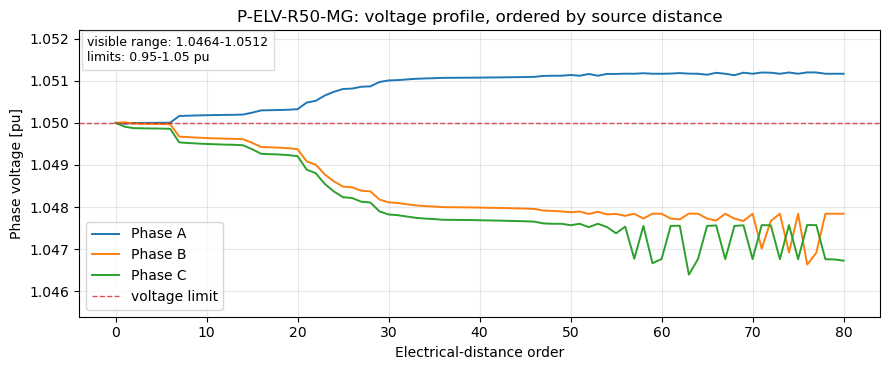

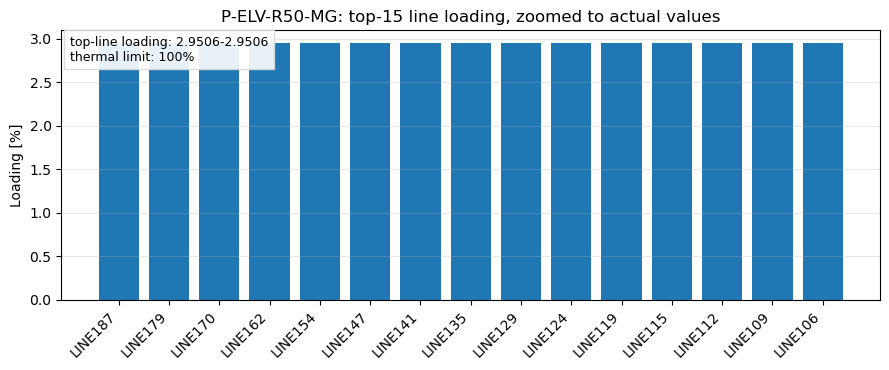

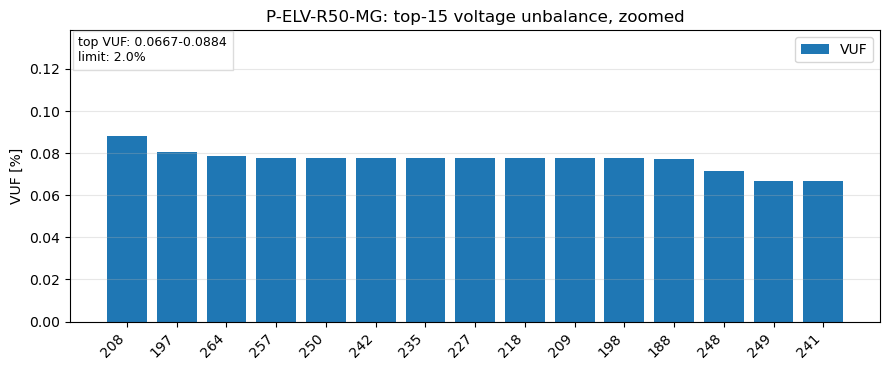

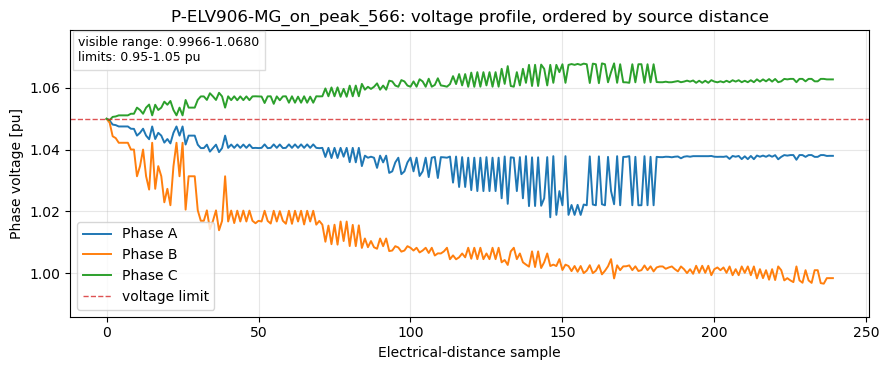

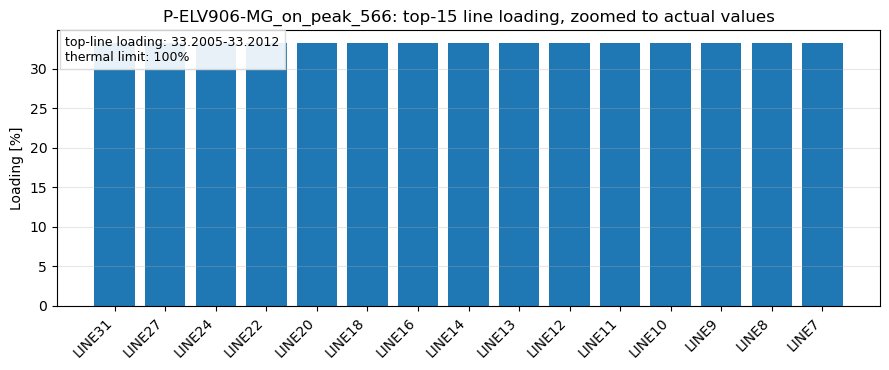

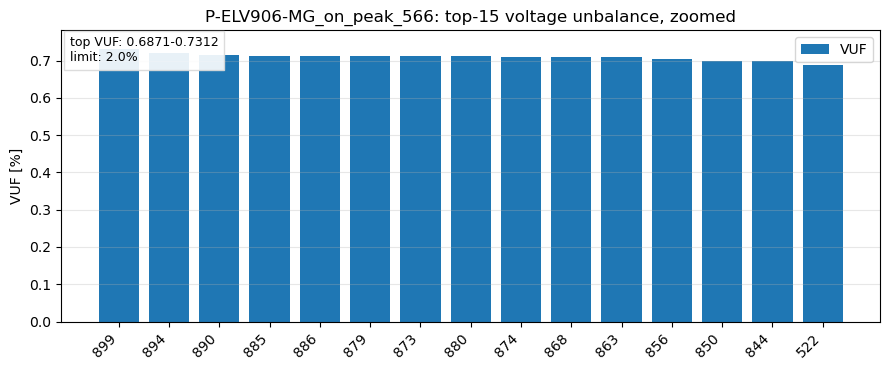

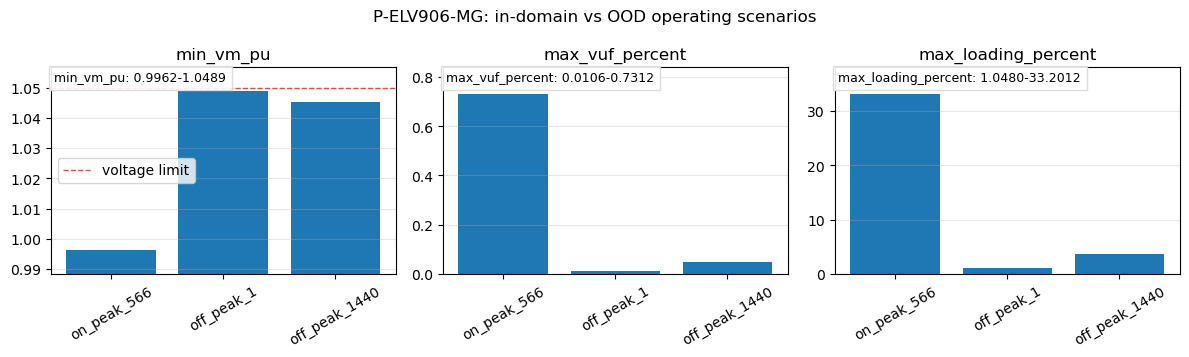

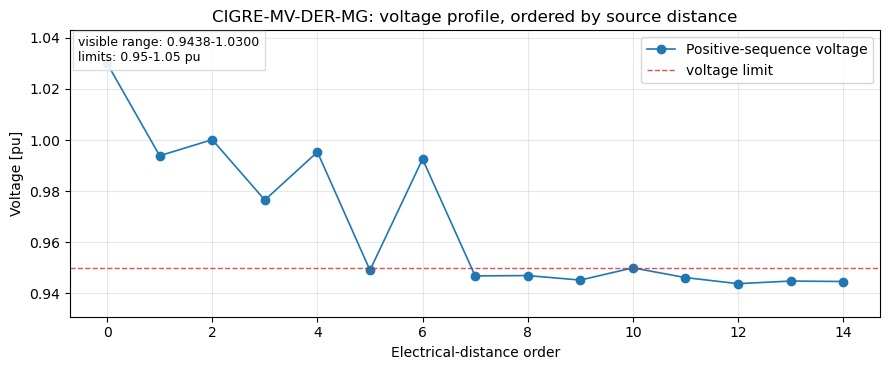

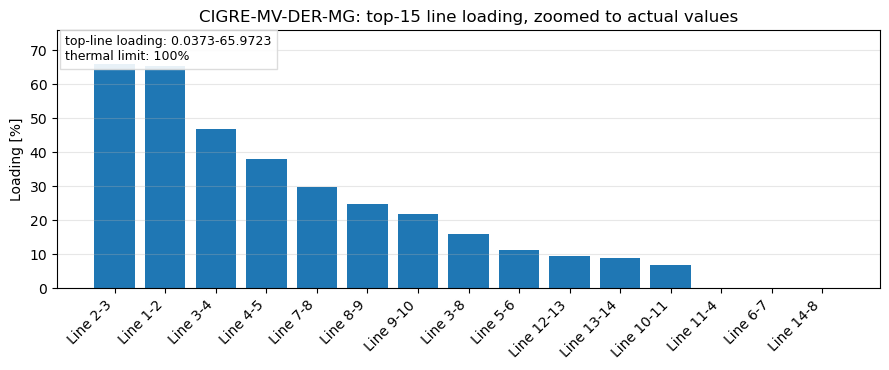

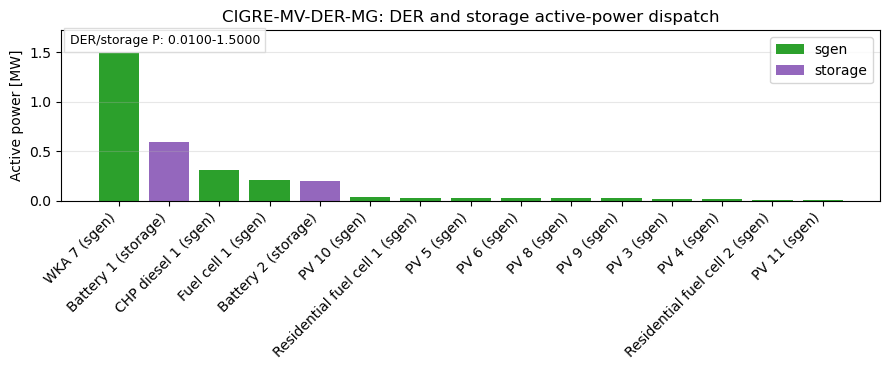

In [22]:
def _sample_index(index: pd.Index, max_points: int = 120) -> pd.Index:
    # Large feeders can have hundreds of buses; sampling keeps plots readable without changing results.
    if len(index) <= max_points:
        return index
    positions = np.unique(np.linspace(0, len(index) - 1, max_points).astype(int))
    return index[positions]


def _bus_profile_order(net: pp.pandapowerNet) -> pd.Index:
    """Order buses by electrical distance from the source for readable feeder profiles."""
    try:
        source = _source_bus(net)
        graph = top.create_nxgraph(net, include_switches=True, include_out_of_service=False, multi=False)
        distances = nx.single_source_shortest_path_length(graph, source)
        ordered = sorted(net.bus.index, key=lambda bus: (distances.get(int(bus), 10**9), int(bus)))
        return pd.Index(ordered)
    except Exception:
        return pd.Index(net.bus.index)


def _set_zoomed_ylim(ax, values, lower_limit=None, upper_limit=None, floor_zero=False) -> tuple[float, float]:
    # Zoom to the actual data range so small but meaningful voltage/loading changes are visible.
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return ax.get_ylim()
    data_min = float(finite.min())
    data_max = float(finite.max())
    span = max(data_max - data_min, 1e-6)
    pad = max(0.15 * span, 0.001 if not floor_zero else 0.05 * max(data_max, 1.0))
    y_min = 0.0 if floor_zero else data_min - pad
    y_max = data_max + pad
    if lower_limit is not None and data_min < lower_limit:
        y_min = min(y_min, lower_limit - pad)
    if upper_limit is not None and data_max > upper_limit:
        y_max = max(y_max, upper_limit + pad)
    ax.set_ylim(y_min, y_max)
    return y_min, y_max


def _draw_threshold_if_visible(ax, value: float, label: str, color: str = "tab:red") -> None:
    y_min, y_max = ax.get_ylim()
    # Draw threshold lines only when they are inside the zoomed axis; otherwise annotate them instead.
    if y_min <= value <= y_max:
        ax.axhline(value, linestyle="--", linewidth=1, color=color, alpha=0.8, label=label)




def _show_legend_if_any(ax) -> None:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="best")


def _annotate_range(ax, values, text_prefix: str, threshold_text: str | None = None) -> None:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return
    text = f"{text_prefix}: {finite.min():.4f}-{finite.max():.4f}"
    if threshold_text:
        text += f"\n{threshold_text}"
    ax.text(
        0.01,
        0.98,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "0.85", "alpha": 0.9},
    )


def plot_paper_case_voltage(case_key: str, max_points: int = 120) -> None:
    net = paper_case_nets[case_key]
    solver = paper_case_solvers[case_key]
    fig, ax = plt.subplots(figsize=(9, 3.8))
    if solver == "runpp_3ph":
        ordered = _bus_profile_order(net).intersection(net.res_bus_3ph.index)
        sample = _sample_index(ordered, max_points=max_points)
        x = np.arange(len(sample))
        plotted_values = []
        for ph in ["a", "b", "c"]:
            y = net.res_bus_3ph.loc[sample, f"vm_{ph}_pu"].to_numpy(dtype=float)
            plotted_values.extend(y)
            ax.plot(x, y, linewidth=1.4, label=f"Phase {ph.upper()}")
        ax.set_ylabel("Phase voltage [pu]")
    else:
        ordered = _bus_profile_order(net).intersection(net.res_bus.index)
        sample = _sample_index(ordered, max_points=max_points)
        x = np.arange(len(sample))
        y = net.res_bus.loc[sample, "vm_pu"].to_numpy(dtype=float)
        plotted_values = list(y)
        ax.plot(x, y, marker="o", linewidth=1.2, label="Positive-sequence voltage")
        ax.set_ylabel("Voltage [pu]")
    _set_zoomed_ylim(ax, plotted_values, lower_limit=PAPER_V_MIN_PU, upper_limit=PAPER_V_MAX_PU)
    _draw_threshold_if_visible(ax, PAPER_V_MIN_PU, "voltage limit")
    _draw_threshold_if_visible(ax, PAPER_V_MAX_PU, "voltage limit")
    _annotate_range(ax, plotted_values, "visible range", f"limits: {PAPER_V_MIN_PU:.2f}-{PAPER_V_MAX_PU:.2f} pu")
    ax.set_title(f"{case_key}: voltage profile, ordered by source distance")
    ax.set_xlabel("Electrical-distance order" if len(sample) == len(ordered) else "Electrical-distance sample")
    ax.grid(True, alpha=0.3)
    _show_legend_if_any(ax)
    fig.tight_layout()
    plt.show()


def plot_paper_case_top_loading(case_key: str, top_n: int = 15) -> None:
    net = paper_case_nets[case_key]
    solver = paper_case_solvers[case_key]
    if _table_len(net, "line") == 0:
        print(f"{case_key}: no lines to plot.")
        return
    if solver == "runpp_3ph":
        loading = net.res_line_3ph["loading_percent"].sort_values(ascending=False).head(top_n)
    else:
        loading = net.res_line["loading_percent"].sort_values(ascending=False).head(top_n)
    labels = _result_name_series(net, "line", loading.index).to_list()
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.bar(np.arange(len(loading)), loading.to_numpy())
    _set_zoomed_ylim(ax, loading.to_numpy(), upper_limit=PAPER_LOADING_MAX_PERCENT, floor_zero=True)
    _draw_threshold_if_visible(ax, PAPER_LOADING_MAX_PERCENT, "loading threshold")
    _annotate_range(
        ax,
        loading.to_numpy(),
        "top-line loading",
        f"thermal limit: {PAPER_LOADING_MAX_PERCENT:.0f}%",
    )
    ax.set_xticks(np.arange(len(loading)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Loading [%]")
    ax.set_title(f"{case_key}: top-{top_n} line loading, zoomed to actual values")
    ax.grid(True, axis="y", alpha=0.3)
    _show_legend_if_any(ax)
    fig.tight_layout()
    plt.show()


def plot_paper_case_unbalance_or_der(case_key: str, top_n: int = 15) -> None:
    net = paper_case_nets[case_key]
    solver = paper_case_solvers[case_key]
    fig, ax = plt.subplots(figsize=(9, 3.8))
    if solver == "runpp_3ph":
        vuf = net.res_bus_3ph["unbalance_percent"].sort_values(ascending=False).head(top_n)
        labels = _result_name_series(net, "bus", vuf.index).to_list()
        ax.bar(np.arange(len(vuf)), vuf.to_numpy(), label="VUF")
        _set_zoomed_ylim(ax, vuf.to_numpy(), upper_limit=PAPER_VUF_MAX_PERCENT, floor_zero=True)
        _draw_threshold_if_visible(ax, PAPER_VUF_MAX_PERCENT, "VUF threshold")
        _annotate_range(ax, vuf.to_numpy(), "top VUF", f"limit: {PAPER_VUF_MAX_PERCENT:.1f}%")
        ax.set_xticks(np.arange(len(vuf)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("VUF [%]")
        ax.set_title(f"{case_key}: top-{top_n} voltage unbalance, zoomed")
    else:
        der_frames = []
        if _table_len(net, "sgen"):
            sgen_frame = net.sgen[["name", "p_mw"]].copy()
            sgen_frame["element"] = "sgen"
            der_frames.append(sgen_frame)
        if _table_len(net, "storage"):
            storage_frame = net.storage[["name", "p_mw"]].copy()
            storage_frame["element"] = "storage"
            der_frames.append(storage_frame)
        if not der_frames:
            print(f"{case_key}: no DER-like sgen/storage table to plot.")
            plt.close(fig)
            return
        der = pd.concat(der_frames).sort_values("p_mw", ascending=False).head(top_n)
        labels = [f"{row.name} ({row.element})" for row in der.itertuples()]
        colors = ["tab:green" if element == "sgen" else "tab:purple" for element in der["element"]]
        ax.bar(np.arange(len(der)), der["p_mw"].to_numpy(), color=colors)
        _set_zoomed_ylim(ax, der["p_mw"].to_numpy(), floor_zero=True)
        _annotate_range(ax, der["p_mw"].to_numpy(), "DER/storage P")
        ax.set_xticks(np.arange(len(der)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("Active power [MW]")
        ax.set_title(f"{case_key}: DER and storage active-power dispatch")
        from matplotlib.patches import Patch
        ax.legend(
            handles=[
                Patch(facecolor="tab:green", label="sgen"),
                Patch(facecolor="tab:purple", label="storage"),
            ],
            loc="best",
        )
    _show_legend_if_any(ax)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_elv906_ood_comparison(summary_df: pd.DataFrame) -> None:
    rows = summary_df.loc[[idx for idx in summary_df.index if idx.startswith("P-ELV906-MG")]].copy()
    labels = rows["scenario"].to_list()
    metrics = ["min_vm_pu", "max_vuf_percent", "max_loading_percent"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3.6))
    for ax, metric in zip(axes, metrics):
        values = rows[metric].to_numpy(dtype=float)
        ax.bar(labels, values)
        if metric == "min_vm_pu":
            _set_zoomed_ylim(ax, values, lower_limit=PAPER_V_MIN_PU, upper_limit=PAPER_V_MAX_PU)
            _draw_threshold_if_visible(ax, PAPER_V_MIN_PU, "voltage limit")
            _draw_threshold_if_visible(ax, PAPER_V_MAX_PU, "voltage limit")
        elif metric == "max_vuf_percent":
            _set_zoomed_ylim(ax, values, upper_limit=PAPER_VUF_MAX_PERCENT, floor_zero=True)
            _draw_threshold_if_visible(ax, PAPER_VUF_MAX_PERCENT, "VUF threshold")
        else:
            _set_zoomed_ylim(ax, values, upper_limit=PAPER_LOADING_MAX_PERCENT, floor_zero=True)
            _draw_threshold_if_visible(ax, PAPER_LOADING_MAX_PERCENT, "loading threshold")
        _annotate_range(ax, values, metric)
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=30)
        ax.grid(True, axis="y", alpha=0.3)
        _show_legend_if_any(ax)
    fig.suptitle("P-ELV906-MG: in-domain vs OOD operating scenarios")
    fig.tight_layout()
    plt.show()


plot_paper_case_voltage("P-ELV-R50-MG")
plot_paper_case_top_loading("P-ELV-R50-MG")
plot_paper_case_unbalance_or_der("P-ELV-R50-MG")

plot_paper_case_voltage(f"P-ELV906-MG_{ELV_BASE_SCENARIO}", max_points=240)
plot_paper_case_top_loading(f"P-ELV906-MG_{ELV_BASE_SCENARIO}")
plot_paper_case_unbalance_or_der(f"P-ELV906-MG_{ELV_BASE_SCENARIO}")
plot_elv906_ood_comparison(paper_case_summary)

plot_paper_case_voltage("CIGRE-MV-DER-MG")
plot_paper_case_top_loading("CIGRE-MV-DER-MG")
plot_paper_case_unbalance_or_der("CIGRE-MV-DER-MG")
